## Written document was added title "Capstone EDA Response"

## Load Database

In [1]:
# Code to assess Postgres SQL came from previous class assignment
import psycopg2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

def execute_query(query):
    try:
        # connect to a PostgresSQL database
        conn = psycopg2.connect(
        host="localhost",
        database="Capstone",   # sepcify dataabse to connect to
        user="postgres",        # deafult user name
        password="Boeing747!")      # password
        
        # create a cursor
        cur = conn.cursor()
        # execute query
        cur.execute(query)
        
        # fetch the result and store into a python dataframe
        rows=cur.fetchall()
        colnames = [desc[0] for desc in cur.description]
        return pd.DataFrame(rows, columns = colnames)
        
    except (Exception, psycopg2.DatabaseError) as error:
        print(error)
    finally:
        if conn is not None:
            conn.close()        # close the communication with the PostgreSQL

In [2]:
# Import Packages
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [3]:
# Pull data
query = """
SELECT * FROM accidents;
"""
df = execute_query(query)

# Display data
pd.set_option('display.max.columns',None)
df.head(3)

,Reporting Railroad Code,Reporting Railroad Name,Year,Accident Number,PDF Link,Accident Year,Accident Month,Other Railroad Code,Other Railroad Name,Other Accident Number,Other Accident Year,Other Accident Month,Maintenance Railroad Code,Maintenance Railroad Name,Maintenance Accident Number,Maintenance Accident Year,Maintenance Accident Month,Grade Crossing ID,Day,Date,Time,Accident Type Code,Accident Type,Hazmat Cars,Hazmat Cars Damaged,Hazmat Released Cars,Persons Evacuated,Subdivision,Division Code,Division,Station,Milepost,State Code,State Abbreviation,State Name,County Code,County Name,District,Temperature,Visibility Code,Visibility,Weather Condition Code,Weather Condition,Track Type Code,Track Type,Track Name,Track Class,Track Density,Train Direction Code,Train Direction,Equipment Type Code,Equipment Type,Equipment Attended,Train Number,Train Speed,Recorded Estimated Speed,Maximum Speed,Gross Tonnage,Signalization Code,Signalization,Method of Operation Code,Method of Operation,Adjunct Code 1,Adjunct Name 1,Adjunct Code 2,Adjunct Name 2,Adjunct Code 3,Adjunct Name 3,Remote Control Locomotive Code,Remote Control Locomotive,First Car Initials,First Car Number,First Car Position,First Car Loaded,Causing Car Initials,Causing Car Number,Causing Car Position,Causing Car Loaded,Positive Alcohol Tests,Positive Drug Tests,Passengers Transported,Head End Locomotives,Mid Train Manual Locomotives,Mid Train Remote Locomotives,Rear End Manual Locomotives,Rear End Remote Locomotives,Derailed Head End Locomotives,Derailed Mid Train Manual Locomotives,Derailed Mid Train Remote Locomotives,Derailed Rear End Manual Locomotives,Derailed Rear End Remote Locomotives,Loaded Freight Cars,Loaded Passenger Cars,Empty Freight Cars,Empty Passenger Cars,Cabooses,Derailed Loaded Freight Cars,Derailed Loaded Passenger Cars,Derailed Empty Freight Cars,Derailed Empty Passenger Cars,Derailed Cabooses,Equipment Damage Cost,Track Damage Cost,Total Damage Cost,Primary Accident Cause Code,Primary Accident Cause,Contributing Accident Cause Code,Contributing Accident Cause,Accident Cause Code,Accident Cause,Engineers On Duty,Firemen On Duty,Conductors On Duty,Brakemen On Duty,Hours Engineers On Duty,Minutes Engineers On Duty,Hours Conductors On Duty,Minutes Conductors On Duty,Railroad Employees Killed,Railroad Employees Injured,Passengers Killed,Passengers Injured,Others Killed,Others Injured,Reporting Railroad Fatalities for 55a,Reporting Railroad Injuries for 55a,Total Persons Killed,Total Persons Injured,Total Killed Form 54,Total Injured Form 54,Special Study 1,Special Study 2,Latitude,Longitude,Narrative,Joint Track Type,Joint Track Class,Class Code,Class,Joint CD,Incident Key,Report Key,Reporting Railroad Class,Reporting Railroad SMT Grouping,Reporting Parent Railroad Code,Reporting Parent Railroad Name,Reporting Railroad Holding Company,Reporting Railroad Individual Class,Reporting Railroad Passenger,Reporting Railroad Commuter,Reporting Railroad Switching Terminal,Reporting Railroad Tourist,Reporting Railroad Freight,Reporting Railroad Short Line,Location
0,CSX,CSX Transportation,2010,74979,https://safetydata.fra.dot.gov/Officeofsafety/...,10,4,None,None,None,NaN,NaN,CSX,CSX Transportation,74979,10.0,4.0,None,16,4/16/2010,1:15 AM,1,Derailment,0,0,0,0,None,ALBANY,ALBANY,SELKIRK,15,36,NY,NEW YORK,1.0,ALBANY,1,53,4.0,Dark,3.0,Rain,2,Yard,SOUTH MASTER,1,0,3,East,5,Single Car,No,None,4.0,Estimated,4.0,0,NaN,None,LN,None,None,None,None,None,None,None,0,Not a remotely controlled operation,ASOX,58690,1.0,No,ASOX,58690.0,1.0,No,NaN,NaN,No,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,17189,1200,18389,E67C,Damaged flange or tread (build up),None,None,E67C,Damaged flange or tread (build up),0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,None,None,0.0,0.0,DERAILED AT RETARDER DUE TO EXCESSIVE BUILD UP.,Yard,1,1,1,1,CSX000074979201004,CSX000074979201004,Class I,SMT-9 - CSX,CSX,CSX Transportation,CSX Transportation,Class I,Unassigned,Unassigned,Unassigned,Unassigne

In [4]:
# Check data shape
df.shape

(224704, 155)

In [5]:
# Dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224704 entries, 0 to 224703
Columns: 155 entries, Reporting Railroad Code to Location
dtypes: float64(25), int64(49), object(81)
memory usage: 265.7+ MB


In [6]:
# Check summary stats
df.describe()

,Year,Accident Year,Accident Month,Other Accident Year,Other Accident Month,Maintenance Accident Year,Maintenance Accident Month,Day,Accident Type Code,Hazmat Cars,Hazmat Cars Damaged,Hazmat Released Cars,Persons Evacuated,State Code,County Code,District,Temperature,Visibility Code,Weather Condition Code,Train Speed,Maximum Speed,Gross Tonnage,Signalization Code,First Car Position,Causing Car Number,Causing Car Position,Positive Alcohol Tests,Positive Drug Tests,Head End Locomotives,Mid Train Manual Locomotives,Mid Train Remote Locomotives,Rear End Manual Locomotives,Rear End Remote Locomotives,Derailed Head End Locomotives,Derailed Mid Train Manual Locomotives,Derailed Mid Train Remote Locomotives,Derailed Rear End Manual Locomotives,Derailed Rear End Remote Locomotives,Loaded Freight Cars,Loaded Passenger Cars,Empty Freight Cars,Empty Passenger Cars,Cabooses,Derailed Loaded Freight Cars,Derailed Loaded Passenger Cars,Derailed Empty Freight Cars,Derailed Empty Passenger Cars,Derailed Cabooses,Equipment Damage Cost,Track Damage Cost,Total Damage Cost,Engineers On Duty,Firemen On Duty,Conductors On Duty,Brakemen On Duty,Hours Engineers On Duty,Minutes Engineers On Duty,Hours Conductors On Duty,Minutes Conductors On Duty,Railroad Employees Killed,Railroad Employees Injured,Passengers Killed,Passengers Injured,Others Killed,Others Injured,Reporting Railroad Fatalities for 55a,Reporting Railroad Injuries for 55a,Total Persons Killed,Total Persons Injured,Total Killed Form 54,Total Injured Form 54,Latitude,Longitude,Joint CD
count,224704.000000,224704.000000,224704.000000,19502.000000,19502.000000,224702.000000,224702.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,221055.000000,224704.000000,224704.000000,224465.000000,224312.000000,224702.000000,224704.000000,224704.000000,37570.000000,211348.000000,26427.000000,107098.000000,78916.000000,79205.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,2.247040e+05,2.247040e+05,2.247040e+05,199038.000000,184614.00000,197111.000000,190859.000000,176489.000000,167594.000000,170363.000000,162556.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,224704.000000,70136.000000,70152.000000,224704.000000
mean,1993.240200,57.764641,6.432872,57.673110,6.440929,57.764942,6.432876,15.684420,3.406508,1.354395,0.176459,0.016413,2.074850,29.268629,94.890584,4.409962,56.180095,2.831515,1.558793,11.607645,13.421151,3185.369402,1.702103,21.563890,219457.990199,8.105996,0.004955,0.006969,1.985100,0.014174,0.017263,0.047342,0.028202,0.141769,0.001032,0.001455,0.003222,0.002323,29.659134,0.212684,16.494566,0.081952,0.277138,2.369815,0.017614,1.095806,0.010000,0.036666,4.374842e+04,1.777318e+04,7.815716e+04,0.935218,0.10718,0.876141,1.040711,4.687408,26.801085,4.625429,26.339428,0.002109,0.057035,0.000877,0.045580,0.010832,0.032385,0.015078,0.158974,0.019417,0.210566,0.010378,0.126869,20.263719,-49.744623,1.311508
std,15.200545,35.285135,3.453805,35.158877,3.461773,35.285149,3.453787,8.753871,3.902550,6.391976,1.037951,0.272891,143.245314,15.312463,95.075204,1.952934,22.995552,1.032728,0.987067,15.245363,15.910348,4395.418992,0.457340,28.422412,278946.002192,21.269043,0.079683,0.091018,1.537901,0.219293,0.223655,0.316720,0.214434,0.541746,0.048463,0.054870,0.081858,0.062963,33.563973,1.677979,26.349023,0.910165,1.660067,4.343923,0.350662,3.355111,0.172761,2.388762,2.181525e+05,1.249053e+05,3.530435e+05,0.365798,0.31426,0.379462,0.897437,2.887727,17.027758,2.936813,17.257065,0.061685,0.426506,0.118978,2.290319,0.134842,2.545053,0.206705,3.435767,0.259472,3.844788,0.183276,3.406570,19.174951,47.166292,0.678269
min,19

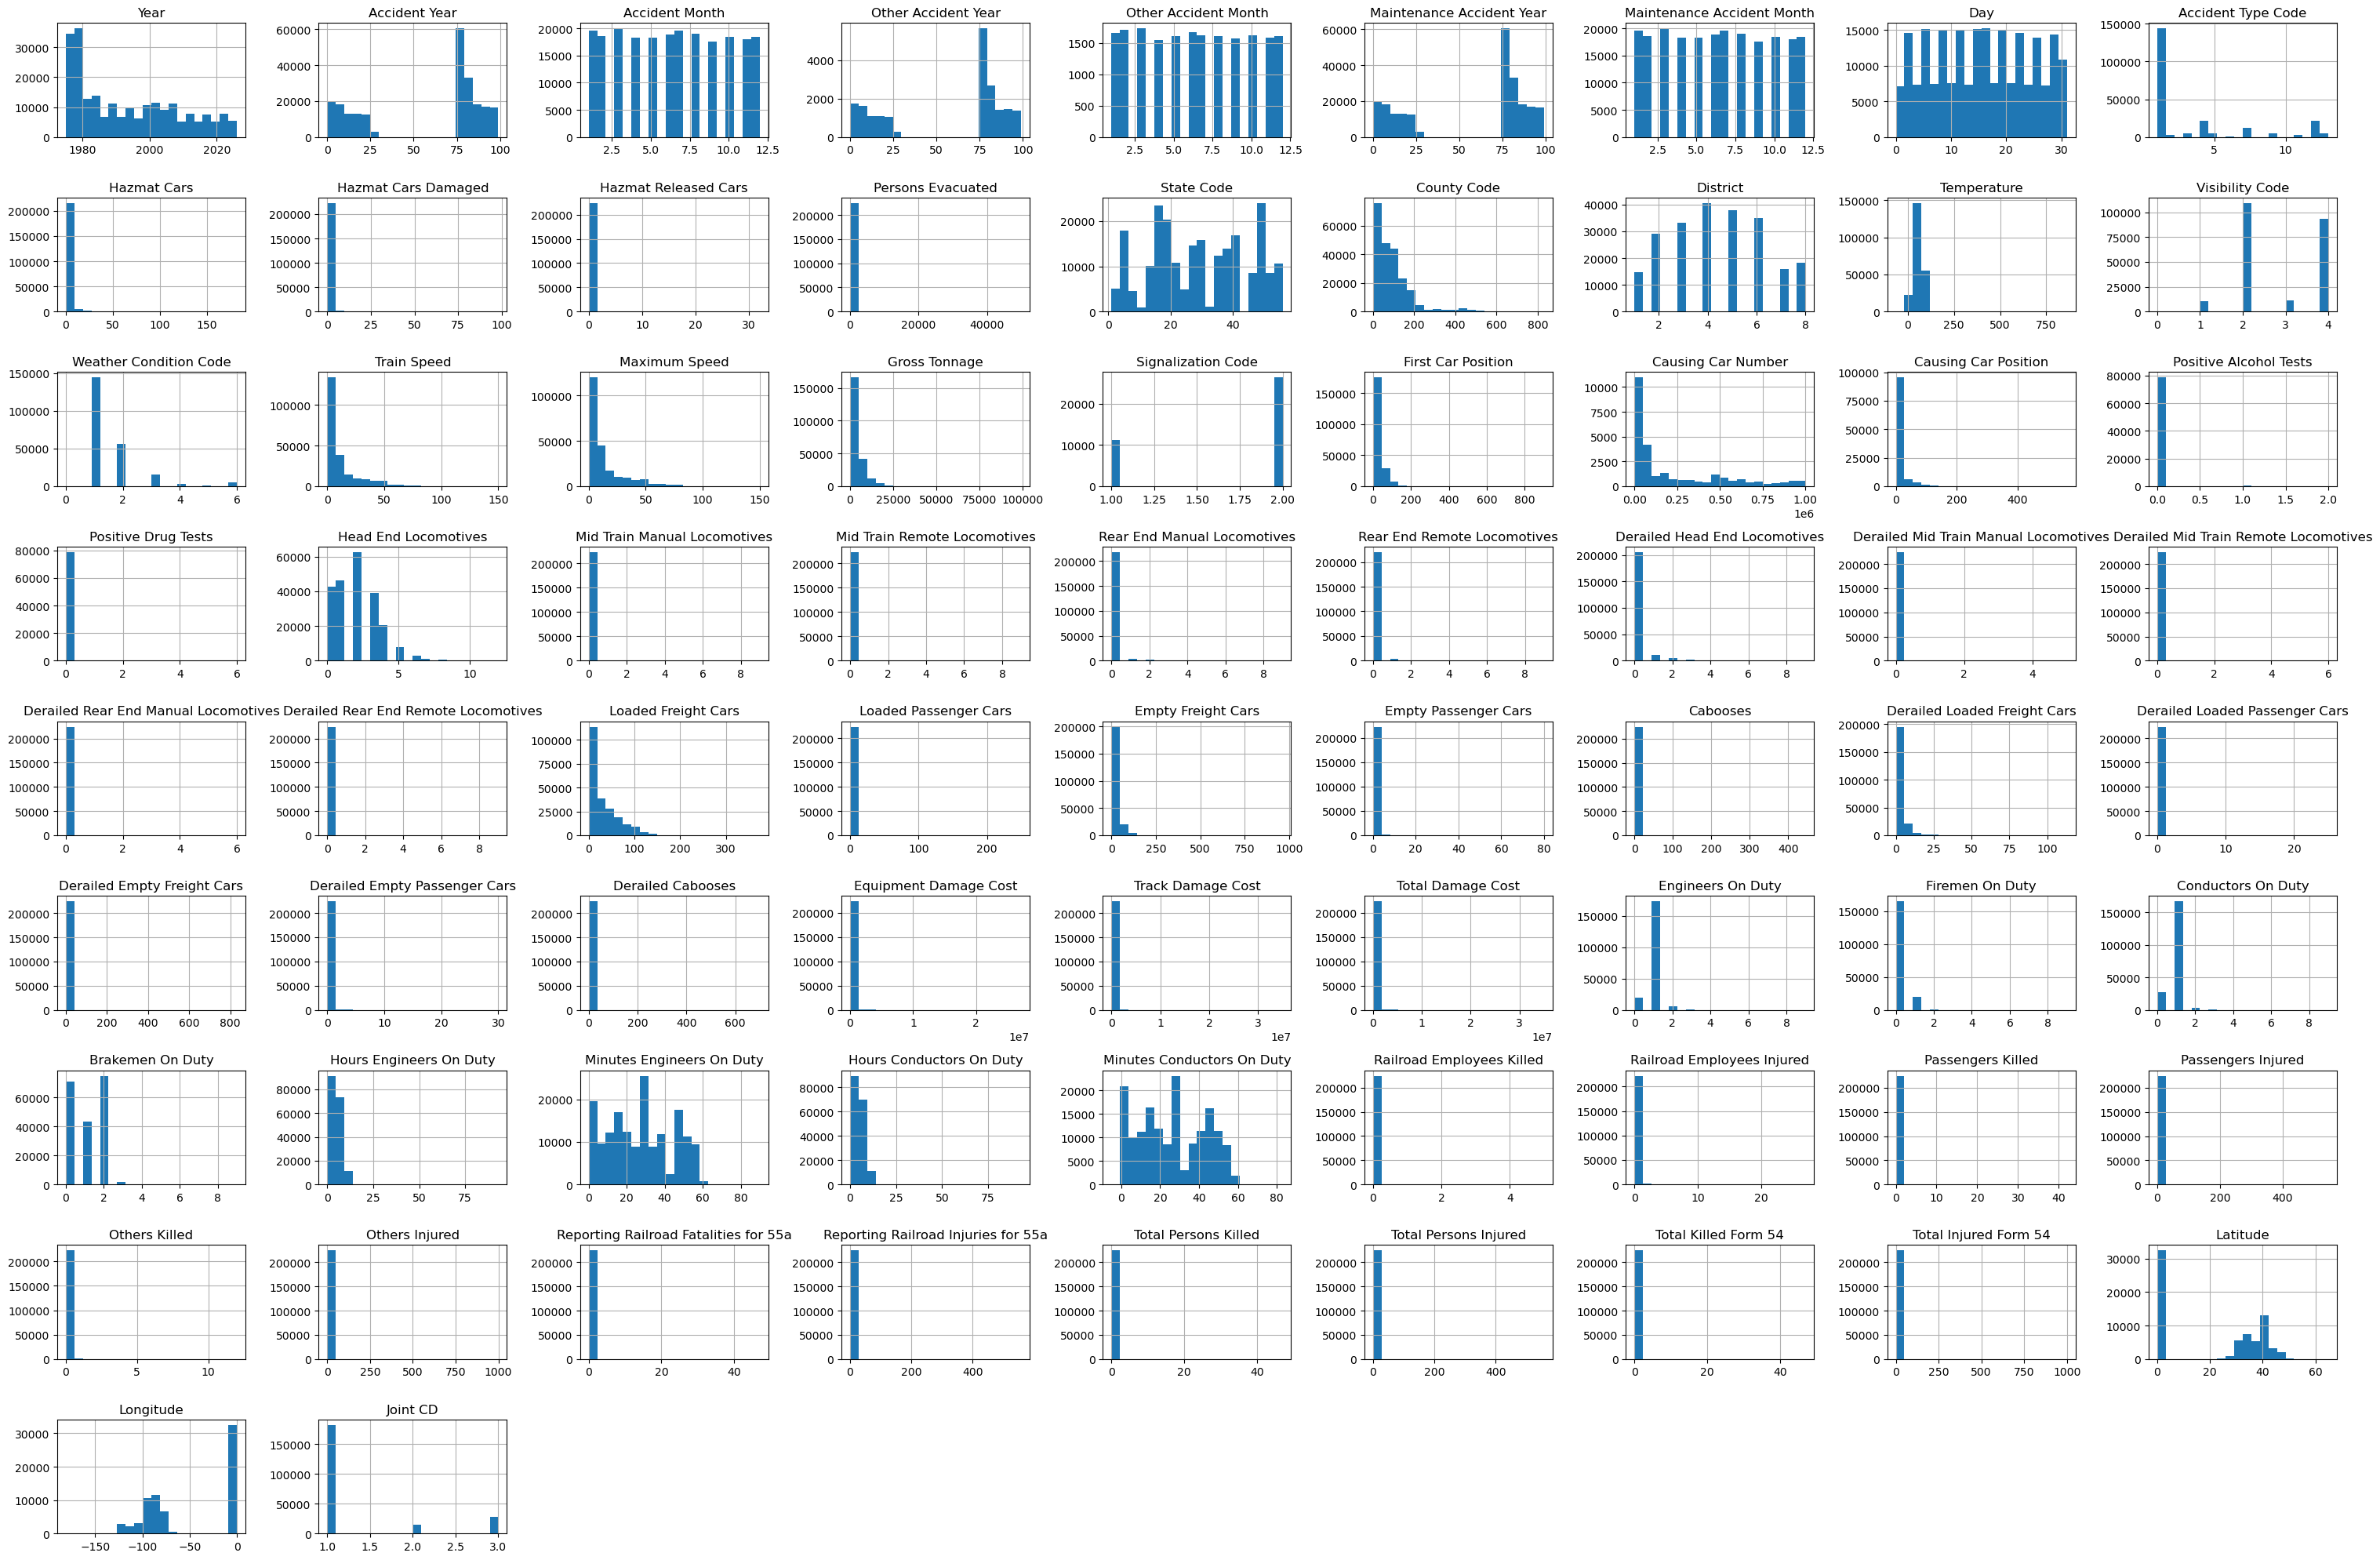

In [7]:
# Display distribution of numeric features
dist = df.hist(figsize=(30,20), bins = 20)
plt.tight_layout()
plt.show()

### Feature Name Correction

In [8]:
# Reformatting column names
# Turn columns to lowercase
df.columns = df.columns.str.lower()

# Remove space between columns
df.columns = df.columns.str.replace(" ","")
df.columns

Index(['reportingrailroadcode', 'reportingrailroadname', 'year',
       'accidentnumber', 'pdflink', 'accidentyear', 'accidentmonth',
       'otherrailroadcode', 'otherrailroadname', 'otheraccidentnumber',
       ...
       'reportingparentrailroadname', 'reportingrailroadholdingcompany',
       'reportingrailroadindividualclass', 'reportingrailroadpassenger',
       'reportingrailroadcommuter', 'reportingrailroadswitchingterminal',
       'reportingrailroadtourist', 'reportingrailroadfreight',
       'reportingrailroadshortline', 'location'],
      dtype='object', length=155)

### Missing Value Exploration

In [9]:
# Check missing values
# Reformat pd setup options
pd.set_option('display.max_rows', None)
missing_values = df.isnull().sum()
missing_values

reportingrailroadcode                      0
reportingrailroadname                      3
year                                       0
accidentnumber                             0
pdflink                                    4
accidentyear                               0
accidentmonth                              0
otherrailroadcode                     205206
otherrailroadname                     205261
otheraccidentnumber                   205199
otheraccidentyear                     205202
otheraccidentmonth                    205202
maintenancerailroadcode                    3
maintenancerailroadname                   89
maintenanceaccidentnumber                  2
maintenanceaccidentyear                    2
maintenanceaccidentmonth                   2
gradecrossingid                       212593
day                                        0
date                                       1
time                                       0
accidenttypecode                           0
accidentty

In [10]:
# Features with more then 25% of records being 'Null' were filter for analysis
missing_percent = df.isnull().sum() * 100 / len(df) # Missing values / total
df2 = pd.DataFrame({'Percent Missing': missing_percent}) # Seperate into features
percent_miss_df = df2[df2['Percent Missing'] > 10.0] # Slice the data that is over 10% missing
percent_miss_df

,Percent Missing
otherrailroadcode,91.322807
otherrailroadname,91.347284
otheraccidentnumber,91.319692
otheraccidentyear,91.321027
otheraccidentmonth,91.321027
gradecrossingid,94.610243
subdivision,83.281562
divisioncode,19.871030
division,18.568428
milepost,13.164875


### Duplicated Review

In [11]:
# Total number of duplicated values
df.duplicated().sum()

np.int64(5)

In [12]:
# Display duplicates
df[df.duplicated(keep=False)] # Keeps all records that are considered duplicated

,reportingrailroadcode,reportingrailroadname,year,accidentnumber,pdflink,accidentyear,accidentmonth,otherrailroadcode,otherrailroadname,otheraccidentnumber,otheraccidentyear,otheraccidentmonth,maintenancerailroadcode,maintenancerailroadname,maintenanceaccidentnumber,maintenanceaccidentyear,maintenanceaccidentmonth,gradecrossingid,day,date,time,accidenttypecode,accidenttype,hazmatcars,hazmatcarsdamaged,hazmatreleasedcars,personsevacuated,subdivision,divisioncode,division,station,milepost,statecode,stateabbreviation,statename,countycode,countyname,district,temperature,visibilitycode,visibility,weatherconditioncode,weathercondition,tracktypecode,tracktype,trackname,trackclass,trackdensity,traindirectioncode,traindirection,equipmenttypecode,equipmenttype,equipmentattended,trainnumber,trainspeed,recordedestimatedspeed,maximumspeed,grosstonnage,signalizationcode,signalization,methodofoperationcode,methodofoperation,adjunctcode1,adjunctname1,adjunctcode2,adjunctname2,adjunctcode3,adjunctname3,remotecontrollocomotivecode,remotecontrollocomotive,firstcarinitials,firstcarnumber,firstcarposition,firstcarloaded,causingcarinitials,causingcarnumber,causingcarposition,causingcarloaded,positivealcoholtests,positivedrugtests,passengerstransported,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,derailedheadendlocomotives,derailedmidtrainmanuallocomotives,derailedmidtrainremotelocomotives,derailedrearendmanuallocomotives,derailedrearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,derailedloadedfreightcars,derailedloadedpassengercars,derailedemptyfreightcars,derailedemptypassengercars,derailedcabooses,equipmentdamagecost,trackdamagecost,totaldamagecost,primaryaccidentcausecode,primaryaccidentcause,contributingaccidentcausecode,contributingaccidentcause,accidentcausecode,accidentcause,engineersonduty,firemenonduty,conductorsonduty,brakemenonduty,hoursengineersonduty,minutesengineersonduty,hoursconductorsonduty,minutesconductorsonduty,railroademployeeskilled,railroademployeesinjured,passengerskilled,passengersinjured,otherskilled,othersinjured,reportingrailroadfatalitiesfor55a,reportingrailroadinjuriesfor55a,totalpersonskilled,totalpersonsinjured,totalkilledform54,totalinjuredform54,specialstudy1,specialstudy2,latitude,longitude,narrative,jointtracktype,jointtrackclass,classcode,class,jointcd,incidentkey,reportkey,reportingrailroadclass,reportingrailroadsmtgrouping,reportingparentrailroadcode,reportingparentrailroadname,reportingrailroadholdingcompany,reportingrailroadindividualclass,reportingrailroadpassenger,reportingrailroadcommuter,reportingrailroadswitchingterminal,reportingrailroadtourist,reportingrailroadfreight,reportingrailroadshortline,location
112373,UP,Union Pacific Railroad Company,1985,0885NP001,https://safetydata.fra.dot.gov/Officeofsafety/...,85,8,None,None,None,NaN,NaN,UP,Union Pacific Railroad Company,0885NP001,85.0,8.0,None,1,8/1/1985,10:30 AM,4,Side collision,0,0,0,0,None,NEBRAS,NEBRASKA,NORTH PLATTE,None,31,NE,NEBRASKA,111.0,LINCOLN,6,69,2.0,Day,2.0,Cloudy,2,Yard,FORWARDING TRACK,2,None,4,West,6,Cut of cars,No,CUT,0.0,Estimated,10.0,0,NaN,None,N,None,None,None,None,None,None,None,None,None,TTGX,962651,18.0,Yes,None,NaN,NaN,None,NaN,NaN,No,0,0,0,0,0,0,0,0,0,0,38,0,1,0,0,3,0,0,0,0,75000,0,368600,H306,"Shoving movement, absence of man on or at lead...",None,None,H306,"Shoving movement, absence of man on or at lead...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,1,0,1,0,0,None,None,NaN,NaN,SEE OTHER REPORTNoneNoneNoneNoneNoneNoneNoneNo...,Yard,2,1L,1L,3,UP0885NP001198508,UP0885NP001198508,Class I,SMT-6 - UP/KCS,UP,Union Pacific Railroad Company,Union Pacific Railroad Company,Class I,Unassigned,Unassigned,Unassigned,Unassigned,Yes,Unassigned,None
112779,UP,Union Pacific Railroad Company,1985,0885NP001,https://safetydata.fra.dot.gov/Officeofsafety/...,85,8,None,None,None,NaN,NaN,UP,Union Pacific Railroad 

In [13]:
# Remove duplicates due to identical ID numbers
df = df.drop_duplicates()
print(df.duplicated().sum())

0


### Initial Features Removed

In [14]:
# Removed columns based on excel file description and investigation from missing values
remove_list = ['reportingrailroadname',
               'maintenanceaccidentnumber',
               'maintenancerailroadname',
               'maintenanceaccidentyear',
               'maintenanceaccidentmonth',
               'date',
               'accidenttypecode',
               'statecode',
               'statename',
               'traindirectioncode',
               'equipmenttypecode',
               'pdflink',
               'divisioncode',
               'milepost',
               'countycode',
               'visibility',
               'weathercondition',
               'trackdensity',
               'trackclass',
               'tracktypecode',
               'causingcarposition',
               'firstcarloaded',
               'firstcarposition',
               'firstcarnumber',
               'firstcarinitials',
               'methodofoperationcode',
               'primaryaccidentcause',
               'accidentcause',
               'hoursengineersonduty',
               'minutesengineersonduty',
               'hoursconductorsonduty',
               'minutesconductorsonduty',
               'narrative',
               'jointtracktype',
               'classcode',
               'otherrailroadcode',
               'otherrailroadname',
               'otheraccidentnumber',
               'otheraccidentyear',
               'otheraccidentmonth',
               'gradecrossingid',
               'signalizationcode',
               'adjunctcode1',
               'adjunctname1',
               'adjunctcode2',
               'adjunctname2',
               'adjunctcode3',
               'adjunctname3',
               'contributingaccidentcausecode',
               'contributingaccidentcause',
               'subdivision',
               'signalization',
               'methodofoperation',
               'remotecontrollocomotivecode',
               'remotecontrollocomotive',
               'causingcarinitials',
               'causingcarnumber',
               'causingcarloaded',
               'location',
               'specialstudy1',
               'specialstudy2',
               'latitude',
               'longitude',
               'reportingparentrailroadname',
               'jointcd',
               'equipmenttype',
               'reportkey',
               'reportingrailroadclass', 
               'reportingrailroadsmtgrouping',
               'reportingparentrailroadcode', 
               'reportingrailroadholdingcompany', 
               'reportingrailroadindividualclass',
               'reportingrailroadpassenger', 
               'reportingrailroadcommuter',
               'reportingrailroadswitchingterminal', 
               'reportingrailroadtourist',
               'reportingrailroadfreight', 
               'reportingrailroadshortline',
               'accidentnumber',
               'incidentkey']

In [15]:
# Drop columns from list and review shape
df = df.drop(columns = remove_list)
df.shape

(224699, 75)

### Handle data points

In [16]:
# df['name'].value_counts() was used to analyze and determine solution
# Handle "Nulls" intensionally
df['positivealcoholtests'] = df['positivealcoholtests'].fillna(0.0)
df['positivedrugtests'] = df['positivedrugtests'].fillna(0.0)
df['equipmentattended'] = df['equipmentattended'].fillna('Unknown')
df['trainspeed'] = df['trainspeed'].fillna(df['trainspeed'].median())
df['passengerstransported'] = df['passengerstransported'].fillna('Unknown')
df['engineersonduty'] = df['engineersonduty'].fillna(0.0)
df['firemenonduty'] = df['firemenonduty'].fillna(0.0)
df['conductorsonduty'] = df['conductorsonduty'].fillna(0.0)
df['brakemenonduty'] = df['brakemenonduty'].fillna(0.0)

# Change data type found during exploration
df['district'] = df['district'].astype('str')
df['visibilitycode'] = df['visibilitycode'].astype('str')
df['weatherconditioncode'] = df['weatherconditioncode'].astype('str')

# Filter out "confusing" values
# Group_A
df = df[df['recordedestimatedspeed'].isin(['Estimated','Recorded'])]
df = df[df['accidenttype'] != 'Other (describe in narrative)']
df = df[(df['temperature'] < 110) & (df['temperature'] > -20)]
df = df[df['visibilitycode'] != 0.0]
df = df[(df['equipmentattended'] != '7') & (df['equipmentattended'] != '0')]
df = df[df['loadedfreightcars'] <= 140]
df = df[df['emptyfreightcars'] <= 140]
df = df[df['emptypassengercars'] <= 20]
df = df[df['cabooses'] <= 5]
df = df[df['engineersonduty'] <= 5]
df = df[df['firemenonduty'] <= 3]
df = df[df['conductorsonduty'] <= 4]
df = df[df['brakemenonduty'] <= 4]
df = df[(df['jointtrackclass'] != 'O') & (df['jointtrackclass'] != 'x')]
df = df[(df['class'] != '0') & (df['class'] != 'Ne') & (df['class'] != 'No')]
df['class'] = df['class'].replace('Cl','CL')

#Group_B
df = df[df['derailedloadedpassengercars'] <= 12]
df = df[df['derailedloadedfreightcars'] <= 50]
df = df[df['derailedrearendremotelocomotives'] <= 2]
df = df[df['derailedrearendmanuallocomotives'] <= 4]
df = df[df['derailedemptyfreightcars'] <= 40]
df = df[df['derailedemptypassengercars'] <= 6]
df = df[df['derailedcabooses'] <= 4]
df = df[df['hazmatcarsdamaged'] <= 20]
df = df[df['hazmatreleasedcars'] <= 7]
df = df[df['hazmatreleasedcars'] <= 7]
df = df[df['positivedrugtests'] <= 2.0]

# Fixing date features
drop_year = ['accidentyear']
# Drop columns from list and review shape
df = df.drop(columns = drop_year, errors = 'ignore')
df = df.rename(columns={'year': 'accidentyear'})
df = df.rename(columns={'day': 'accidentday'})

In [17]:
# Review shape
df.shape

(200443, 74)

### Removing Missing Values

In [18]:
# Check missing values
df.isnull().sum()

reportingrailroadcode                    0
accidentyear                             0
accidentmonth                            0
maintenancerailroadcode                  2
accidentday                              0
time                                     0
accidenttype                             0
hazmatcars                               0
hazmatcarsdamaged                        0
hazmatreleasedcars                       0
personsevacuated                         0
division                             35761
station                                188
stateabbreviation                        0
countyname                            3282
district                                 0
temperature                              0
visibilitycode                           0
weatherconditioncode                     0
tracktype                             2120
trackname                             2337
traindirection                       10749
equipmentattended                        0
trainnumber

In [19]:
# Removed 'Null" records based on previous analysis
df = df.dropna()

In [20]:
# Double check work
df.shape

(137457, 74)

### Seperating Data (Model features and target features)

In [21]:
# Claude AI was used for efficiency. Based on the provided prompt following prompt, gave advice on what features to seperate into each group.
# Further switching and adjustments where made based upon further investigation.
# Seperated into two groups: (Features used for Prediction) & (Target variable calculator)
group_a = ['reportingrailroadcode',
           'maintenancerailroadcode',
           'accidentyear',
           'accidentmonth', 
           'accidentday',
           'accidenttype',
           'time',  
           'division', 
           'stateabbreviation',
           'countyname', 
           'district',
           'hazmatcars', 
           'temperature', 
           'visibilitycode', 
           'weatherconditioncode', 
           'tracktype',
           'equipmentattended', 
           'trainspeed',
           'recordedestimatedspeed', 
           'maximumspeed', 
           'grosstonnage',
           'passengerstransported',
           'headendlocomotives', 
           'midtrainmanuallocomotives',
           'midtrainremotelocomotives', 
           'rearendmanuallocomotives',
           'rearendremotelocomotives', 
           'loadedfreightcars',
           'loadedpassengercars', 
           'emptyfreightcars', 
           'emptypassengercars',
           'cabooses', 
           'engineersonduty', 
           'firemenonduty', 
           'conductorsonduty',
           'brakemenonduty', 
           'jointtrackclass', 
           'class']

group_b = [
        'equipmentdamagecost',
        'trackdamagecost',
        'totaldamagecost',
        'railroademployeeskilled',
        'railroademployeesinjured',
        'passengerskilled',
        'passengersinjured',
        'otherskilled',
        'othersinjured',
        'reportingrailroadfatalitiesfor55a',
        'reportingrailroadinjuriesfor55a',
        'totalpersonskilled',
        'totalpersonsinjured',
        'totalkilledform54',
        'totalinjuredform54',
        'derailedheadendlocomotives',
        'derailedmidtrainmanuallocomotives',
        'derailedmidtrainremotelocomotives',
        'derailedrearendmanuallocomotives',
        'derailedrearendremotelocomotives',
        'derailedloadedfreightcars',
        'derailedloadedpassengercars',
        'derailedemptyfreightcars',
        'derailedemptypassengercars',
        'derailedcabooses',
        'hazmatcarsdamaged',
        'hazmatreleasedcars',
        'personsevacuated',
        'positivealcoholtests', 
        'positivedrugtests']

In [22]:
# Examining Group A
df_a = df[group_a]
df_a.head(1)

,reportingrailroadcode,maintenancerailroadcode,accidentyear,accidentmonth,accidentday,accidenttype,time,division,stateabbreviation,countyname,district,hazmatcars,temperature,visibilitycode,weatherconditioncode,tracktype,equipmentattended,trainspeed,recordedestimatedspeed,maximumspeed,grosstonnage,passengerstransported,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,engineersonduty,firemenonduty,conductorsonduty,brakemenonduty,jointtrackclass,class
1,BNSF,BNSF,2010,12,24,Derailment,4:30 PM,KANSAS,KS,COWLEY,6,0,35,2.0,2.0,Main,Yes,21.0,Recorded,21.0,14755,No,3,0,0,0,1,114,0,1,0,0,1.0,0.0,1.0,0.0,4,1


In [23]:
# Examining Group B
df_b = df[group_b]
df_b.head(1)

,equipmentdamagecost,trackdamagecost,totaldamagecost,railroademployeeskilled,railroademployeesinjured,passengerskilled,passengersinjured,otherskilled,othersinjured,reportingrailroadfatalitiesfor55a,reportingrailroadinjuriesfor55a,totalpersonskilled,totalpersonsinjured,totalkilledform54,totalinjuredform54,derailedheadendlocomotives,derailedmidtrainmanuallocomotives,derailedmidtrainremotelocomotives,derailedrearendmanuallocomotives,derailedrearendremotelocomotives,derailedloadedfreightcars,derailedloadedpassengercars,derailedemptyfreightcars,derailedemptypassengercars,derailedcabooses,hazmatcarsdamaged,hazmatreleasedcars,personsevacuated,positivealcoholtests,positivedrugtests
1,130746,450000,580746,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11,0,0,0,0,0,0,0,0.0,0.0


### Correcting Time Column

In [24]:
# Reformatting time into two columns for modeling
df_a['time'] = pd.to_datetime(df_a['time'], format = ('%I:%M %p'), errors = 'coerce') # Extra time formatting and convert unreadable values to NA
df_a['accidenthour'] = df_a['time'].dt.hour
df_a['accidentminute'] = df_a['time'].dt.minute

# Dropping the existing time column
df_a = df_a.drop(columns = 'time', axis =1)
df_a.head(1)

,reportingrailroadcode,maintenancerailroadcode,accidentyear,accidentmonth,accidentday,accidenttype,division,stateabbreviation,countyname,district,hazmatcars,temperature,visibilitycode,weatherconditioncode,tracktype,equipmentattended,trainspeed,recordedestimatedspeed,maximumspeed,grosstonnage,passengerstransported,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,engineersonduty,firemenonduty,conductorsonduty,brakemenonduty,jointtrackclass,class,accidenthour,accidentminute
1,BNSF,BNSF,2010,12,24,Derailment,KANSAS,KS,COWLEY,6,0,35,2.0,2.0,Main,Yes,21.0,Recorded,21.0,14755,No,3,0,0,0,1,114,0,1,0,0,1.0,0.0,1.0,0.0,4,1,16.0,30.0


### Group B Feature Review

In [25]:
# Confirm that all the columns are numeric
df_b.info()

<class 'pandas.core.frame.DataFrame'>
Index: 137457 entries, 1 to 224698
Data columns (total 30 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   equipmentdamagecost                137457 non-null  int64  
 1   trackdamagecost                    137457 non-null  int64  
 2   totaldamagecost                    137457 non-null  int64  
 3   railroademployeeskilled            137457 non-null  int64  
 4   railroademployeesinjured           137457 non-null  int64  
 5   passengerskilled                   137457 non-null  int64  
 6   passengersinjured                  137457 non-null  int64  
 7   otherskilled                       137457 non-null  int64  
 8   othersinjured                      137457 non-null  int64  
 9   reportingrailroadfatalitiesfor55a  137457 non-null  int64  
 10  reportingrailroadinjuriesfor55a    137457 non-null  int64  
 11  totalpersonskilled                 137457 no

In [26]:
# Group B description
df_b.describe()

,equipmentdamagecost,trackdamagecost,totaldamagecost,railroademployeeskilled,railroademployeesinjured,passengerskilled,passengersinjured,otherskilled,othersinjured,reportingrailroadfatalitiesfor55a,reportingrailroadinjuriesfor55a,totalpersonskilled,totalpersonsinjured,totalkilledform54,totalinjuredform54,derailedheadendlocomotives,derailedmidtrainmanuallocomotives,derailedmidtrainremotelocomotives,derailedrearendmanuallocomotives,derailedrearendremotelocomotives,derailedloadedfreightcars,derailedloadedpassengercars,derailedemptyfreightcars,derailedemptypassengercars,derailedcabooses,hazmatcarsdamaged,hazmatreleasedcars,personsevacuated,positivealcoholtests,positivedrugtests
count,1.374570e+05,1.374570e+05,1.374570e+05,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000
mean,4.127067e+04,1.449706e+04,6.617805e+04,0.002634,0.066486,0.001142,0.041446,0.012273,0.027587,0.017911,0.166088,0.019402,0.190350,0.010738,0.124555,0.165354,0.001011,0.001579,0.003397,0.001862,2.903053,0.019286,1.257251,0.008701,0.026095,0.180245,0.017096,2.641190,0.002197,0.002226
std,1.645641e+05,7.011122e+04,2.520688e+05,0.070802,0.453884,0.147901,2.120636,0.147544,1.146020,0.241668,3.160511,0.257797,3.315364,0.210836,2.317307,0.595036,0.048314,0.057259,0.081785,0.049406,4.487473,0.330935,2.894636,0.140970,0.166124,0.889376,0.192504,178.987795,0.053221,0.049831
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.800000e+03,0.000000e+00,7.652000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.150000e+03,1.850000e+03,1.510000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.260000e+04,8.000000e+03,3.966900e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000e+07,9.930000e+06,1.693000e+07,5.000000,20.000000,42.000000,546.000000,12.000000,363.000000,47.000000,558.000000,47.000000,558.000000,47.000000,558.000000,9.000000,5.000000,6.000000,4.000000,2.000000,50.000000,12.000000,40.000000,6.000000,4.000000,20.000000,7.000000,50000.000000,2.000000,2.000000


In [27]:
# Feature weights: assigned manually
feature_weights = {
        'equipmentdamagecost': 0.20,
        'trackdamagecost': 0.20,
        'totaldamagecost': 0.40,
        'railroademployeeskilled':0.90,
        'railroademployeesinjured':0.50,
        'passengerskilled':0.90,
        'passengersinjured':0.50,
        'otherskilled':0.90,
        'othersinjured':0.50,
        'reportingrailroadfatalitiesfor55a':0.90,
        'reportingrailroadinjuriesfor55a':0.50,
        'totalpersonskilled':0.90,
        'totalpersonsinjured':0.50,
        'totalkilledform54':0.90,
        'totalinjuredform54':0.50,
        'derailedheadendlocomotives':0.35,
        'derailedmidtrainmanuallocomotives':0.35,
        'derailedmidtrainremotelocomotives':0.35,
        'derailedrearendmanuallocomotives':0.35,
        'derailedrearendremotelocomotives':0.35,
        'derailedloadedfreightcars':0.40,
        'derailedloadedpassengercars':0.50,
        'derailedemptyfreightcars':0.20,
        'derailedemptypassengercars':0.20,
        'derailedcabooses':0.20,
        'hazmatcarsdamaged':0.40,
        'hazmatreleasedcars':0.80,
        'personsevacuated':0.30,
        'positivealcoholtests':0.50, 
        'positivedrugtests':0.50}

# Turn the dictionary into a usable list
feature_weights_list = list(feature_weights.keys())

In [28]:
# Claude AI was use to help trouble shoot coding error
mean_cal = df_b[feature_weights_list].mean() # Calculated the mean of each column
std_cal = df_b[feature_weights_list].std().replace(0,1) # Calculated the std of each column. Replacing 0 with 1 helps prevent being divided by 0. 

z_score =(df_b[feature_weights_list] - mean_cal) / std_cal # Takes the value of X substract the calculated mean divided by the calculated std

weigth_series = pd.Series(feature_weights).reindex(z_score.columns).fillna(0) # Reindex weight dictionary to match order of z score
weighted = z_score.mul(weigth_series, axis = 1) # Take Z score and multiply it by it weights

df_b['risk_score'] = weighted.sum(axis=1) # Sum all weights together into one score

In [29]:
# Calculated column description
df_b['risk_score'].describe()

count    137457.000000
mean          0.000000
std           5.991637
min          -1.429027
25%          -1.240621
50%          -0.966267
75%          -0.366517
max         992.642188
Name: risk_score, dtype: float64

#### Percent/Evaluate Results

In [30]:
# Convert into a percentage
df_b['risk_percentage'] = (df_b['risk_score'] - df_b['risk_score'].min())/ (df_b['risk_score'].max() - df_b['risk_score'].min()) * 100

In [31]:
# Display data
df_b.head(3)

,equipmentdamagecost,trackdamagecost,totaldamagecost,railroademployeeskilled,railroademployeesinjured,passengerskilled,passengersinjured,otherskilled,othersinjured,reportingrailroadfatalitiesfor55a,reportingrailroadinjuriesfor55a,totalpersonskilled,totalpersonsinjured,totalkilledform54,totalinjuredform54,derailedheadendlocomotives,derailedmidtrainmanuallocomotives,derailedmidtrainremotelocomotives,derailedrearendmanuallocomotives,derailedrearendremotelocomotives,derailedloadedfreightcars,derailedloadedpassengercars,derailedemptyfreightcars,derailedemptypassengercars,derailedcabooses,hazmatcarsdamaged,hazmatreleasedcars,personsevacuated,positivealcoholtests,positivedrugtests,risk_score,risk_percentage
1,130746,450000,580746,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11,0,0,0,0,0,0,0,0.0,0.0,1.915622,0.336460
2,0,20000,20000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0.0,0.0,-1.072826,0.035833
5,8550,2000,10550,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12,0,0,0,0,0,0,0,0.0,0.0,-0.326545,0.110906


In [32]:
df_b['risk_percentage'].describe()

count    137457.000000
mean          0.143755
std           0.602737
min           0.000000
25%           0.018953
50%           0.046552
75%           0.106885
max         100.000000
Name: risk_percentage, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

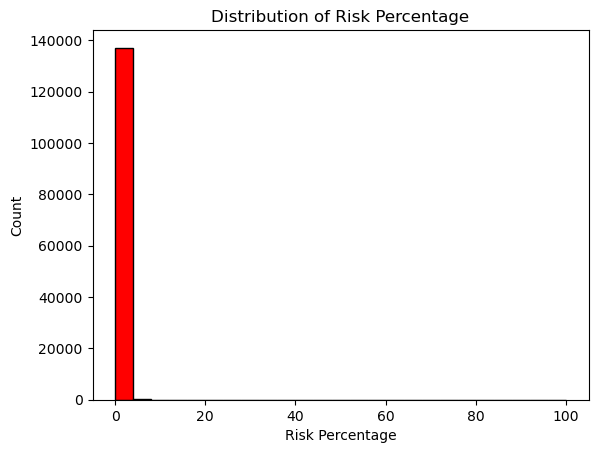

In [33]:
# Data is extremely right skewed
hist = df_b['risk_percentage']
plt.hist(hist,bins=25,color='red',edgecolor='black')
plt.title('Distribution of Risk Percentage')
plt.xlabel('Risk Percentage')
plt.ylabel('Count')
plt.show

### Log Attampt for Scoring

In [34]:
# Claude AI was used to impliment logging technique and understanding data issue
skew_weights = df_b[list(feature_weights.keys())].skew().sort_values(ascending=False) # .skew() calculates the skewness of each column
print(skew_weights) # Display results

othersinjured                        252.475486
passengerskilled                     212.991657
personsevacuated                     206.306212
passengersinjured                    161.597867
totalinjuredform54                   128.352612
reportingrailroadinjuriesfor55a      113.334717
totalkilledform54                    107.362948
totalpersonsinjured                  100.655319
reportingrailroadfatalitiesfor55a     74.590424
totalpersonskilled                    65.945478
derailedmidtrainmanuallocomotives     61.542674
derailedmidtrainremotelocomotives     44.600816
trackdamagecost                       38.156701
railroademployeeskilled               35.965149
derailedrearendmanuallocomotives      30.024341
derailedrearendremotelocomotives      29.808537
positivealcoholtests                  27.192072
positivedrugtests                     24.207435
derailedloadedpassengercars           23.205585
otherskilled                          22.964568
derailedemptypassengercars            22

In [35]:
# Claude AI was used to impliment logging technique and understanding data issue
col_log = list(feature_weights.keys()) # Select keys from dictionary and add them to a list
df_b[col_log] = df_b[col_log].apply(np.log1p) # Apply log1p [log(1+x)]. Better then log(x) as it allows for 0 and negatives.
                                          # It compress large values and reduce skewness. 
df_b[col_log].skew().sort_values(ascending=False) # Calculate shrinked .skew() and display

passengerskilled                     102.876670
derailedmidtrainmanuallocomotives     48.384372
derailedmidtrainremotelocomotives     36.605110
railroademployeeskilled               27.320955
derailedrearendremotelocomotives      26.982294
passengersinjured                     25.082800
positivealcoholtests                  24.620303
derailedrearendmanuallocomotives      24.531384
positivedrugtests                     22.568541
personsevacuated                      16.632762
derailedloadedpassengercars           16.365665
derailedemptypassengercars            16.263141
totalkilledform54                     15.217006
othersinjured                         12.034872
otherskilled                          11.858293
hazmatreleasedcars                    11.272353
reportingrailroadfatalitiesfor55a     11.181338
totalpersonskilled                    11.118421
totalinjuredform54                     7.269044
reportingrailroadinjuriesfor55a        6.297227
totalpersonsinjured                    6

In [36]:
# Claude AI was used to impliment logging technique and understanding data issue
mean_cal_log = df_b[col_log].mean() # Calculated the mean of each column
std_cal_log = df_b[col_log].std().replace(0,1) # Calculated the std of each column.
z_score_log =(df_b[col_log] - mean_cal_log) / std_cal_log # Takes the value of X substract the calculated mean divided by the calculated std.

weigth_series = pd.Series(feature_weights).reindex(group_b).fillna(0) # Reindex weight dictionary to match order of z score
weighted_log = z_score_log.mul(weigth_series, axis = 1) # Take Z score and multiply it by it weights
df_b['risk_score_log'] = weighted_log.sum(axis=1) # Sum all weights together into one score

In [37]:
# Display data description
df_b['risk_score_log'].describe()

count    1.374570e+05
mean     7.939891e-17
std      5.788446e+00
min     -5.875402e+00
25%     -1.845749e+00
50%     -1.237119e+00
75%     -2.982296e-01
max      3.671226e+02
Name: risk_score_log, dtype: float64

#### Percent/Evaluate Results

In [38]:
# Turn score into percentage
df_b['risk_percentage_log'] = (df_b['risk_score_log'] - df_b['risk_score_log'].min())/ (df_b['risk_score_log'].max() - df_b['risk_score_log'].min()) * 100

In [39]:
# Display data
df_b.head(3)

,equipmentdamagecost,trackdamagecost,totaldamagecost,railroademployeeskilled,railroademployeesinjured,passengerskilled,passengersinjured,otherskilled,othersinjured,reportingrailroadfatalitiesfor55a,reportingrailroadinjuriesfor55a,totalpersonskilled,totalpersonsinjured,totalkilledform54,totalinjuredform54,derailedheadendlocomotives,derailedmidtrainmanuallocomotives,derailedmidtrainremotelocomotives,derailedrearendmanuallocomotives,derailedrearendremotelocomotives,derailedloadedfreightcars,derailedloadedpassengercars,derailedemptyfreightcars,derailedemptypassengercars,derailedcabooses,hazmatcarsdamaged,hazmatreleasedcars,personsevacuated,positivealcoholtests,positivedrugtests,risk_score,risk_percentage,risk_score_log,risk_percentage_log
1,11.781019,13.017005,13.272070,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.484907,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.915622,0.336460,0.795166,1.788365
2,0.000000,9.903538,9.903538,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.386294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.072826,0.035833,-1.801846,1.092112
5,9.053804,7.601402,9.263976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.564949,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.326545,0.110906,-0.856751,1.345490


In [40]:
# Data discription
df_b['risk_percentage_log'].describe()

count    137457.000000
mean          1.575183
std           1.551870
min           0.000000
25%           1.080342
50%           1.243514
75%           1.495228
max         100.000000
Name: risk_percentage_log, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

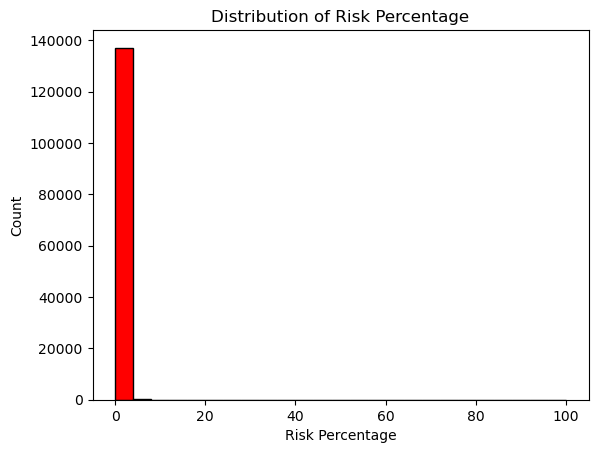

In [41]:
# Display distribution
hist_log = df_b['risk_percentage_log']
plt.hist(hist, bins = 25, color='red', edgecolor = 'black')
plt.title('Distribution of Risk Percentage')
plt.xlabel('Risk Percentage')
plt.ylabel('Count')
plt.show

### Evaluate Outliers

<function matplotlib.pyplot.show(close=None, block=None)>

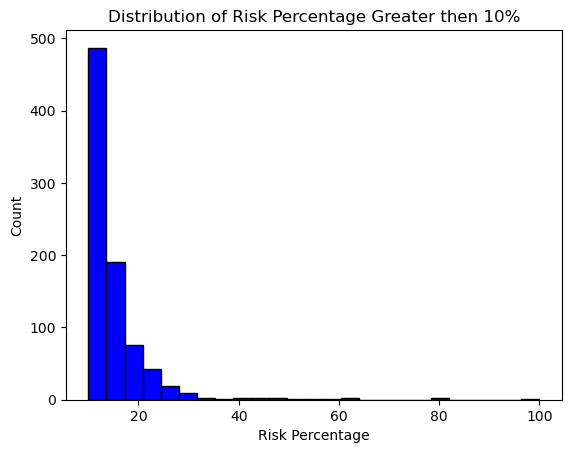

In [42]:
# Slice data to risk score over 10% to review outliers
df_of = df_b[df_b['risk_percentage_log'] > 10.0]
hist = df_of['risk_percentage_log']

# Display distribution
plt.hist(hist, bins = 25, color = 'blue', edgecolor = 'black')
plt.title('Distribution of Risk Percentage Greater then 10%')
plt.xlabel('Risk Percentage')
plt.ylabel('Count')
plt.show

In [43]:
# Display data
df_of.head(10)

,equipmentdamagecost,trackdamagecost,totaldamagecost,railroademployeeskilled,railroademployeesinjured,passengerskilled,passengersinjured,otherskilled,othersinjured,reportingrailroadfatalitiesfor55a,reportingrailroadinjuriesfor55a,totalpersonskilled,totalpersonsinjured,totalkilledform54,totalinjuredform54,derailedheadendlocomotives,derailedmidtrainmanuallocomotives,derailedmidtrainremotelocomotives,derailedrearendmanuallocomotives,derailedrearendremotelocomotives,derailedloadedfreightcars,derailedloadedpassengercars,derailedemptyfreightcars,derailedemptypassengercars,derailedcabooses,hazmatcarsdamaged,hazmatreleasedcars,personsevacuated,positivealcoholtests,positivedrugtests,risk_score,risk_percentage,risk_score_log,risk_percentage_log
521,11.063900,9.615872,11.274985,0.000000,0.693147,0.0,1.791759,0.693147,0.693147,0.693147,2.079442,0.693147,2.079442,0.693147,2.079442,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.790532,2.436401,51.875941,15.483015
2147,14.978662,0.000000,15.010947,0.000000,0.693147,0.0,2.833213,0.000000,0.000000,0.000000,2.890372,0.000000,2.890372,0.000000,2.890372,0.693147,0.0,0.0,0.0,0.0,0.000000,1.386294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.620819,2.821714,37.219554,11.553668
2597,9.457981,0.000000,10.234983,0.000000,0.000000,0.0,0.693147,0.693147,0.000000,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.975162,1.851395,33.507404,10.558448
4182,9.326255,10.907203,11.094314,0.693147,0.000000,0.0,1.386294,0.000000,0.000000,0.000000,1.386294,0.000000,1.386294,0.693147,1.386294,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.106691,1.965223,37.079356,11.516081
4539,8.732143,0.000000,9.500320,0.000000,0.000000,0.0,0.000000,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.144636,1.868444,33.496834,10.555615
4695,11.825742,0.000000,11.882604,0.000000,0.693147,0.0,3.401197,0.000000,0.000000,0.000000,3.433987,0.000000,3.433987,0.000000,3.433987,0.000000,0.0,0.0,0.0,0.0,0.000000,0.693147,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.160340,2.574199,37.432813,11.610843
4784,11.563676,11.896915,12.437256,0.000000,0.693147,0.0,0.000000,0.693147,0.000000,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,1.098612,0.0,0.0,0.0,0.0,1.386294,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.171595,2.172945,35.788217,11.169930
7042,11.521033,0.000000,11.521033,0.000000,0.000000,0.0,0.693147,0.693147,0.000000,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.197882,1.873800,34.057096,10.705820
8567,14.941902,12.807768,15.053754,0.693147,0.693147,0.0,0.000000,0.000000,0.000000,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35.245107,3.689286,44.326370,13.458991
9966,10.192831,0.000000,10.192831,0.000000,0.000000,0.0,0.693147,0.693147,0.000000,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.990231,1.852911,33.553728,10.570868


<function matplotlib.pyplot.show(close=None, block=None)>

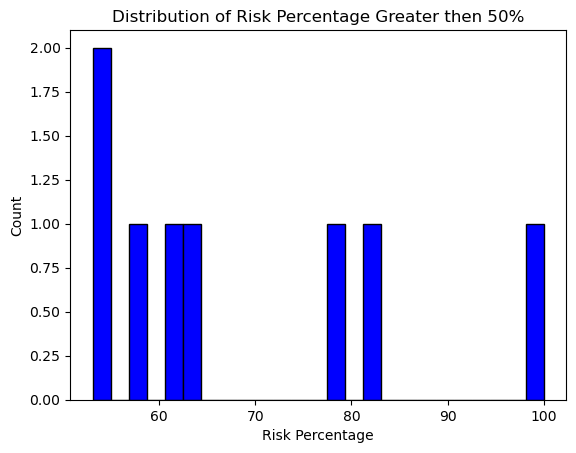

In [44]:
# Increase the threshold to equal to and greater then 50%
df_of_hf = df_b[df_b['risk_percentage_log'] >= 50.0]
hist = df_of_hf['risk_percentage_log']

# Display distribution
plt.hist(hist, bins= 25, color = 'blue', edgecolor = 'black')
plt.title('Distribution of Risk Percentage Greater then 50%')
plt.xlabel('Risk Percentage')
plt.ylabel('Count')
plt.show

In [45]:
# Display data
df_of_hf.head(10)

,equipmentdamagecost,trackdamagecost,totaldamagecost,railroademployeeskilled,railroademployeesinjured,passengerskilled,passengersinjured,otherskilled,othersinjured,reportingrailroadfatalitiesfor55a,reportingrailroadinjuriesfor55a,totalpersonskilled,totalpersonsinjured,totalkilledform54,totalinjuredform54,derailedheadendlocomotives,derailedmidtrainmanuallocomotives,derailedmidtrainremotelocomotives,derailedrearendmanuallocomotives,derailedrearendremotelocomotives,derailedloadedfreightcars,derailedloadedpassengercars,derailedemptyfreightcars,derailedemptypassengercars,derailedcabooses,hazmatcarsdamaged,hazmatreleasedcars,personsevacuated,positivealcoholtests,positivedrugtests,risk_score,risk_percentage,risk_score_log,risk_percentage_log
59905,16.066802,0.000000,16.085257,0.000000,2.890372,2.484907,3.496508,0.000000,0.000000,2.484907,3.912023,2.484907,3.931826,2.484907,3.912023,1.098612,0.0,0.0,0.0,0.000000,0.000000,2.484907,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,288.666094,29.182529,227.107219,62.462157
74543,16.012735,11.672712,16.385918,0.693147,0.693147,3.218876,4.060443,0.000000,0.000000,3.258097,4.077537,3.258097,4.127134,3.258097,4.077537,0.693147,0.0,0.0,0.0,0.000000,0.000000,0.693147,0.000000,0.000000,0.0,0.000000,0.000000,5.420535,0.000000,0.0,524.346769,52.891160,288.795061,79.000539
87604,15.137267,0.000000,15.708924,1.386294,0.000000,2.197225,2.484907,0.000000,0.000000,2.484907,2.484907,2.484907,3.401197,2.484907,2.197225,0.693147,0.0,0.0,0.0,0.693147,0.000000,0.693147,0.000000,0.693147,0.0,0.000000,0.000000,0.000000,0.000000,0.0,247.843379,25.075910,230.615560,63.402735
92473,16.118096,13.336503,16.246436,1.791759,2.639057,3.761200,4.510860,0.000000,0.000000,3.871201,4.644391,3.871201,4.644391,3.871201,4.634729,1.386294,0.0,0.0,0.0,0.000000,0.000000,2.197225,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,992.642188,100.000000,367.122640,100.000000
100850,14.731802,0.000000,14.758833,0.000000,2.639057,2.197225,2.995732,0.000000,0.000000,2.197225,3.496508,2.197225,3.496508,2.197225,3.465736,0.000000,0.0,0.0,0.0,0.000000,0.000000,1.945910,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,190.681117,19.325592,197.945438,54.643944
103942,16.118096,14.354924,16.354448,0.693147,2.639057,2.772589,5.099866,0.000000,0.000000,2.833213,5.176150,2.833213,5.181784,2.833213,5.176150,1.098612,0.0,0.0,0.0,0.000000,0.000000,2.484907,0.000000,0.693147,0.0,0.000000,0.000000,0.000000,1.098612,0.0,506.717891,51.117758,297.196795,81.253026
152889,12.746905,9.741027,12.795211,1.609438,2.772589,0.000000,0.000000,2.564949,3.401197,2.833213,3.806662,2.833213,3.806662,2.833213,3.806662,0.000000,0.0,0.0,0.0,0.000000,2.079442,0.000000,2.944439,0.000000,0.0,1.098612,0.693147,6.216606,0.000000,0.0,367.425309,37.105424,210.515637,58.013988
165032,13.166382,10.474495,13.231937,1.098612,2.639057,1.609438,3.555348,0.000000,0.000000,1.945910,3.871201,1.945910,3.871201,1.945910,3.871201,1.609438,0.0,0.0,0.0,0.000000,2.197225,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,168.927788,17.137285,192.178169,53.097751


### Correcting Scale

##### IQR Scale

In [46]:
# Claude AI was used as a tool to provide an alternative solutions
# To handle extreme data values, threshold was created to cap points at 100%.

q1 = df_b['risk_percentage_log'].quantile(0.25)
q3 = df_b['risk_percentage_log'].quantile(0.75)
IQR = q3 - q1

threshold = q3 + 1.5 * IQR # This also indicated anything over is an outlier

# Display results in a percentage
df_b['risk_percent_scale'] = (df_b['risk_percentage_log']/threshold) * 100
df_b['risk_percent_scale'] = df_b['risk_percent_scale'].clip(lower=0,upper=100) # .clip was added to cap range at 0 - 100

In [47]:
# Display results
df_b.head(3)

,equipmentdamagecost,trackdamagecost,totaldamagecost,railroademployeeskilled,railroademployeesinjured,passengerskilled,passengersinjured,otherskilled,othersinjured,reportingrailroadfatalitiesfor55a,reportingrailroadinjuriesfor55a,totalpersonskilled,totalpersonsinjured,totalkilledform54,totalinjuredform54,derailedheadendlocomotives,derailedmidtrainmanuallocomotives,derailedmidtrainremotelocomotives,derailedrearendmanuallocomotives,derailedrearendremotelocomotives,derailedloadedfreightcars,derailedloadedpassengercars,derailedemptyfreightcars,derailedemptypassengercars,derailedcabooses,hazmatcarsdamaged,hazmatreleasedcars,personsevacuated,positivealcoholtests,positivedrugtests,risk_score,risk_percentage,risk_score_log,risk_percentage_log,risk_percent_scale
1,11.781019,13.017005,13.272070,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.484907,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.915622,0.336460,0.795166,1.788365,84.454125
2,0.000000,9.903538,9.903538,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.386294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.072826,0.035833,-1.801846,1.092112,51.574106
5,9.053804,7.601402,9.263976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.564949,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.326545,0.110906,-0.856751,1.345490,63.539681


In [48]:
# Data description
df_b['risk_percent_scale'].describe()

count    137457.000000
mean         63.022094
std          17.023187
min           0.000000
25%          51.018271
50%          58.723954
75%          70.610963
max         100.000000
Name: risk_percent_scale, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

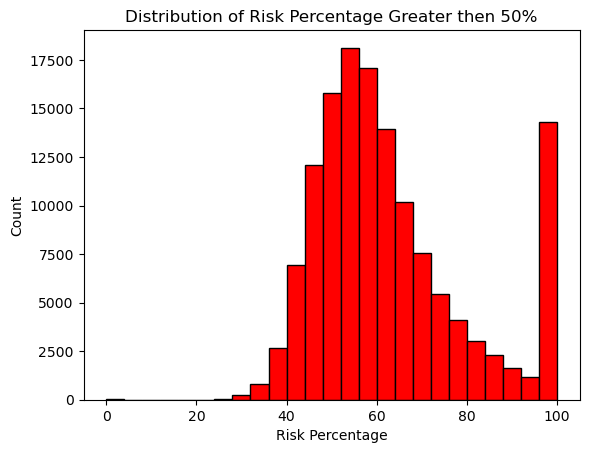

In [49]:
# Data distribution
hist = df_b['risk_percent_scale']
plt.hist(hist,bins=25,color='red',edgecolor='black')
plt.title('Distribution of Risk Percentage Greater then 50%')
plt.xlabel('Risk Percentage')
plt.ylabel('Count')
plt.show

##### Auto Selecting Threshold

In [50]:
# Manually select threshold value through trial and error to show best results
threshold = df_b['risk_percentage_log'].quantile(0.95) # 0.90 and 0.99 were tested

# Display results in percentage
df_b['risk_percent_scale'] = (df_b['risk_percentage_log']/threshold) * 100
df_b['risk_percent_scale'] = df_b['risk_percent_scale'].clip(lower=0,upper=100)

In [51]:
# Display data
df_b.head(3)

,equipmentdamagecost,trackdamagecost,totaldamagecost,railroademployeeskilled,railroademployeesinjured,passengerskilled,passengersinjured,otherskilled,othersinjured,reportingrailroadfatalitiesfor55a,reportingrailroadinjuriesfor55a,totalpersonskilled,totalpersonsinjured,totalkilledform54,totalinjuredform54,derailedheadendlocomotives,derailedmidtrainmanuallocomotives,derailedmidtrainremotelocomotives,derailedrearendmanuallocomotives,derailedrearendremotelocomotives,derailedloadedfreightcars,derailedloadedpassengercars,derailedemptyfreightcars,derailedemptypassengercars,derailedcabooses,hazmatcarsdamaged,hazmatreleasedcars,personsevacuated,positivealcoholtests,positivedrugtests,risk_score,risk_percentage,risk_score_log,risk_percentage_log,risk_percent_scale
1,11.781019,13.017005,13.272070,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.484907,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.915622,0.336460,0.795166,1.788365,53.438041
2,0.000000,9.903538,9.903538,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.386294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.072826,0.035833,-1.801846,1.092112,32.633328
5,9.053804,7.601402,9.263976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.564949,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.326545,0.110906,-0.856751,1.345490,40.204502


In [52]:
# Display description
df_b['risk_percent_scale'].describe()

count    137457.000000
mean         42.506646
std          17.824825
min           0.000000
25%          32.281626
50%          37.157369
75%          44.678830
max         100.000000
Name: risk_percent_scale, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

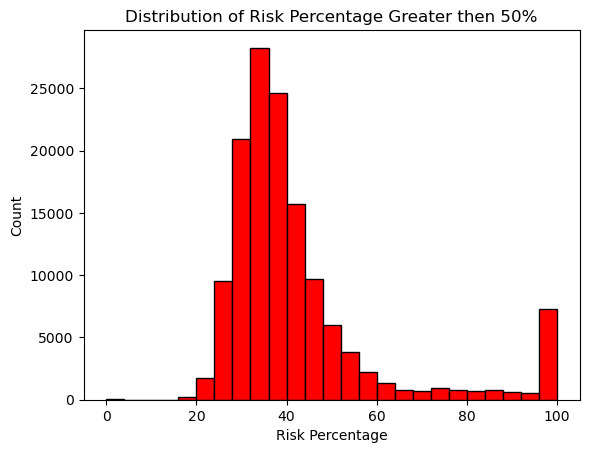

In [53]:
# Display distribution
hist = df_b['risk_percent_scale']
plt.hist(hist,bins=25,color='red',edgecolor='black')
plt.title('Distribution of Risk Percentage Greater then 50%')
plt.xlabel('Risk Percentage')
plt.ylabel('Count')
plt.show

#### Add Target Variable to Group A

In [54]:
# Add target variable to Group A data
df_a['risk_percentage'] = df_b['risk_percent_scale']
df_a.index.equals(df_b.index) # Used to determine in the index of both dataframes matched

# Display data
df_a.head(3)

,reportingrailroadcode,maintenancerailroadcode,accidentyear,accidentmonth,accidentday,accidenttype,division,stateabbreviation,countyname,district,hazmatcars,temperature,visibilitycode,weatherconditioncode,tracktype,equipmentattended,trainspeed,recordedestimatedspeed,maximumspeed,grosstonnage,passengerstransported,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,engineersonduty,firemenonduty,conductorsonduty,brakemenonduty,jointtrackclass,class,accidenthour,accidentminute,risk_percentage
1,BNSF,BNSF,2010,12,24,Derailment,KANSAS,KS,COWLEY,6,0,35,2.0,2.0,Main,Yes,21.0,Recorded,21.0,14755,No,3,0,0,0,1,114,0,1,0,0,1.0,0.0,1.0,0.0,4,1,16.0,30.0,53.438041
2,RT,RT,1989,10,5,Derailment,SYSTEM,OH,CUYAHOGA,2,0,60,4.0,2.0,Yard,Yes,5.0,Estimated,5.0,0,No,2,0,0,0,0,16,0,0,0,0,1.0,0.0,1.0,2.0,1,3S,1.0,30.0,32.633328
5,BO,BO,1981,1,15,Derailment,PENNSYLVANIA,PA,ELK,2,0,20,4.0,2.0,Main,Yes,16.0,Recorded,16.0,7500,No,4,0,0,0,0,62,0,28,0,1,1.0,0.0,1.0,2.0,3,1L,22.0,35.0,40.204502


### Risk Category

In [55]:
# Copied and manually filtered based on previous weight feature dictionary
fin_weights = {
        'equipmentdamagecost': 0.20,
        'trackdamagecost': 0.20,
        'totaldamagecost': 0.40,}

leg_weights = {
        'railroademployeeskilled':0.90,
        'railroademployeesinjured':0.50,
        'passengerskilled':0.90,
        'passengersinjured':0.50,
        'otherskilled':0.90,
        'othersinjured':0.50,
        'derailedheadendlocomotives':0.35,
        'derailedmidtrainmanuallocomotives':0.35,
        'derailedmidtrainremotelocomotives':0.35,
        'derailedrearendmanuallocomotives':0.35,
        'derailedrearendremotelocomotives':0.35,
        'derailedloadedfreightcars':0.40,
        'derailedloadedpassengercars':0.50,
        'derailedemptyfreightcars':0.20,
        'derailedemptypassengercars':0.20,
        'derailedcabooses':0.20,
        'reportingrailroadfatalitiesfor55a':0.90,
        'reportingrailroadinjuriesfor55a':0.50,
        'totalpersonskilled':0.90,
        'totalpersonsinjured':0.50,
        'totalkilledform54':0.90,
        'totalinjuredform54':0.50,
        'hazmatcarsdamaged':0.40,
        'hazmatreleasedcars':0.80,
        'personsevacuated':0.30,
        'positivealcoholtests':0.50, 
        'positivedrugtests':0.50}

##### Financial Risk

In [56]:
# Turn the dictionary into a usable list
fin_weights_list = list(fin_weights.keys())

mean_cal = df_b[fin_weights_list].mean() # Calculated the mean of each column
std_cal = df_b[fin_weights_list].std().replace(0,1) # Calculated the std of each column. Replacing 0 with 1 helps prevent being divided by 0. 
z_score =(df_b[fin_weights_list] - mean_cal) / std_cal # Takes the value of X substract the calculated mean divided by the calculated std

fin_series = pd.Series(fin_weights).reindex(group_b).fillna(0) # Reindex weight dictionary to order of Group B to match order of z score
fin_weighted = z_score.mul(fin_series, axis = 1) # Take Z score and multiply it by it weights
df_b['risk_fin_score'] = fin_weighted.sum(axis=1) # Sum all weights together into one score

In [57]:
# Display data
df_b.head(3)

,equipmentdamagecost,trackdamagecost,totaldamagecost,railroademployeeskilled,railroademployeesinjured,passengerskilled,passengersinjured,otherskilled,othersinjured,reportingrailroadfatalitiesfor55a,reportingrailroadinjuriesfor55a,totalpersonskilled,totalpersonsinjured,totalkilledform54,totalinjuredform54,derailedheadendlocomotives,derailedmidtrainmanuallocomotives,derailedmidtrainremotelocomotives,derailedrearendmanuallocomotives,derailedrearendremotelocomotives,derailedloadedfreightcars,derailedloadedpassengercars,derailedemptyfreightcars,derailedemptypassengercars,derailedcabooses,hazmatcarsdamaged,hazmatreleasedcars,personsevacuated,positivealcoholtests,positivedrugtests,risk_score,risk_percentage,risk_score_log,risk_percentage_log,risk_percent_scale,risk_fin_score
1,11.781019,13.017005,13.272070,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.484907,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.915622,0.336460,0.795166,1.788365,53.438041,1.613819
2,0.000000,9.903538,9.903538,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.386294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.072826,0.035833,-1.801846,1.092112,32.633328,-0.493287
5,9.053804,7.601402,9.263976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.564949,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.326545,0.110906,-0.856751,1.345490,40.204502,-0.073792


In [58]:
# Display description
df_b['risk_fin_score'].describe()

count    1.374570e+05
mean     6.616576e-17
std      6.215301e-01
min     -3.948649e+00
25%     -4.288760e-01
50%     -8.729402e-02
75%      3.426905e-01
max      3.095696e+00
Name: risk_fin_score, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

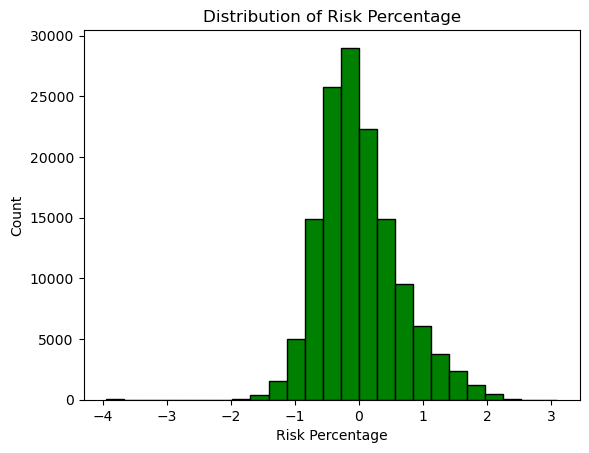

In [59]:
# Display distribution
hist = df_b['risk_fin_score']
plt.hist(hist,bins=25,color='green',edgecolor='black')
plt.title('Distribution of Risk Percentage')
plt.xlabel('Risk Percentage')
plt.ylabel('Count')
plt.show

##### Legal Risk

In [60]:
# Turn the dictionary into a usable list
leg_weights_list = list(leg_weights.keys())

mean_cal = df_b[leg_weights_list].mean() # Calculated the mean of each column
std_cal = df_b[leg_weights_list].std().replace(0,1) # Calculated the std of each column. Replacing 0 with 1 helps prevent being divided by 0. 
z_score =(df_b[leg_weights_list] - mean_cal) / std_cal # Takes the value of X substract the calculated mean divided by the calculated std

leg_series = pd.Series(leg_weights).reindex(group_b).fillna(0) # Reindex weight dictionary to order of Group B to match order of z score
leg_weighted = z_score.mul(leg_series, axis = 1) # Take Z score and multiply it by it weights
df_b['risk_leg_score'] = leg_weighted.sum(axis=1) # Sum all weights together into one score

In [61]:
# Display data
df_b.head(3)

,equipmentdamagecost,trackdamagecost,totaldamagecost,railroademployeeskilled,railroademployeesinjured,passengerskilled,passengersinjured,otherskilled,othersinjured,reportingrailroadfatalitiesfor55a,reportingrailroadinjuriesfor55a,totalpersonskilled,totalpersonsinjured,totalkilledform54,totalinjuredform54,derailedheadendlocomotives,derailedmidtrainmanuallocomotives,derailedmidtrainremotelocomotives,derailedrearendmanuallocomotives,derailedrearendremotelocomotives,derailedloadedfreightcars,derailedloadedpassengercars,derailedemptyfreightcars,derailedemptypassengercars,derailedcabooses,hazmatcarsdamaged,hazmatreleasedcars,personsevacuated,positivealcoholtests,positivedrugtests,risk_score,risk_percentage,risk_score_log,risk_percentage_log,risk_percent_scale,risk_fin_score,risk_leg_score
1,11.781019,13.017005,13.272070,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.484907,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.915622,0.336460,0.795166,1.788365,53.438041,1.613819,-0.818653
2,0.000000,9.903538,9.903538,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.386294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.072826,0.035833,-1.801846,1.092112,32.633328,-0.493287,-1.308560
5,9.053804,7.601402,9.263976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.564949,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.326545,0.110906,-0.856751,1.345490,40.204502,-0.073792,-0.782959


In [62]:
# Display description
df_b['risk_leg_score'].describe()

count    1.374570e+05
mean    -1.323315e-17
std      5.636139e+00
min     -1.926753e+00
25%     -1.617656e+00
50%     -1.209053e+00
75%     -6.903663e-01
max      3.642563e+02
Name: risk_leg_score, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

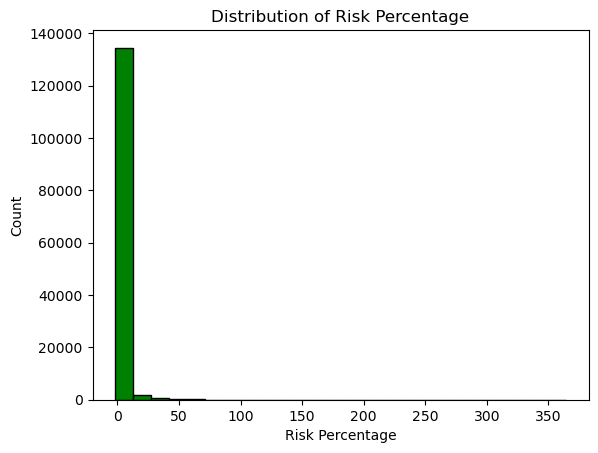

In [63]:
# Display distribution
hist = df_b['risk_leg_score']
plt.hist(hist,bins=25,color='green',edgecolor='black')
plt.title('Distribution of Risk Percentage')
plt.xlabel('Risk Percentage')
plt.ylabel('Count')
plt.show

#### Risk Category Creation

In [64]:
# Claude AI was used to trouble shoot logic from previous version - streamline the code 
def risk_category(x):
    fin_eval = x['risk_fin_score'] > 0 # If finance is present, its value will be greater then the average (0)
    leg_pres = x['risk_leg_score'] > 0 # If legal is present, its value will be greater then the average (0)

    if fin_eval and leg_pres:
        return 'Combination Risk'
    elif fin_eval and not leg_pres:
        return 'Financial Risk'
    elif not fin_eval and leg_pres:
        return 'Legal Risk'
    else:
        return 'Minimal Risk'

# Add 'risk_category' to dataframe
df_b['risk_category'] = df_b.apply(risk_category, axis=1)
df_b.head(3)

,equipmentdamagecost,trackdamagecost,totaldamagecost,railroademployeeskilled,railroademployeesinjured,passengerskilled,passengersinjured,otherskilled,othersinjured,reportingrailroadfatalitiesfor55a,reportingrailroadinjuriesfor55a,totalpersonskilled,totalpersonsinjured,totalkilledform54,totalinjuredform54,derailedheadendlocomotives,derailedmidtrainmanuallocomotives,derailedmidtrainremotelocomotives,derailedrearendmanuallocomotives,derailedrearendremotelocomotives,derailedloadedfreightcars,derailedloadedpassengercars,derailedemptyfreightcars,derailedemptypassengercars,derailedcabooses,hazmatcarsdamaged,hazmatreleasedcars,personsevacuated,positivealcoholtests,positivedrugtests,risk_score,risk_percentage,risk_score_log,risk_percentage_log,risk_percent_scale,risk_fin_score,risk_leg_score,risk_category
1,11.781019,13.017005,13.272070,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.484907,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.915622,0.336460,0.795166,1.788365,53.438041,1.613819,-0.818653,Financial Risk
2,0.000000,9.903538,9.903538,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.386294,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.072826,0.035833,-1.801846,1.092112,32.633328,-0.493287,-1.308560,Minimal Risk
5,9.053804,7.601402,9.263976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.564949,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.326545,0.110906,-0.856751,1.345490,40.204502,-0.073792,-0.782959,Minimal Risk


In [65]:
# Check category value count
# Class imbalance handling step will need to be implimented during model building
df_b['risk_category'].value_counts()

risk_category
Minimal Risk        69017
Financial Risk      47493
Combination Risk    12869
Legal Risk           8078
Name: count, dtype: int64

In [66]:
# Add column to dataframe Group A
df_a['risk_category'] = df_b['risk_category']
df_a.index.equals(df_b.index) # Used to determine in the index of both dataframes matched
df_a.head(10)

,reportingrailroadcode,maintenancerailroadcode,accidentyear,accidentmonth,accidentday,accidenttype,division,stateabbreviation,countyname,district,hazmatcars,temperature,visibilitycode,weatherconditioncode,tracktype,equipmentattended,trainspeed,recordedestimatedspeed,maximumspeed,grosstonnage,passengerstransported,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,engineersonduty,firemenonduty,conductorsonduty,brakemenonduty,jointtrackclass,class,accidenthour,accidentminute,risk_percentage,risk_category
1,BNSF,BNSF,2010,12,24,Derailment,KANSAS,KS,COWLEY,6,0,35,2.0,2.0,Main,Yes,21.0,Recorded,21.0,14755,No,3,0,0,0,1,114,0,1,0,0,1.0,0.0,1.0,0.0,4,1,16.0,30.0,53.438041,Financial Risk
2,RT,RT,1989,10,5,Derailment,SYSTEM,OH,CUYAHOGA,2,0,60,4.0,2.0,Yard,Yes,5.0,Estimated,5.0,0,No,2,0,0,0,0,16,0,0,0,0,1.0,0.0,1.0,2.0,1,3S,1.0,30.0,32.633328,Minimal Risk
5,BO,BO,1981,1,15,Derailment,PENNSYLVANIA,PA,ELK,2,0,20,4.0,2.0,Main,Yes,16.0,Recorded,16.0,7500,No,4,0,0,0,0,62,0,28,0,1,1.0,0.0,1.0,2.0,3,1L,22.0,35.0,40.204502,Minimal Risk
6,PTRA,PTRA,1981,1,23,Derailment,HOUSTON,TX,HARRIS,5,0,35,3.0,1.0,Main,Yes,7.0,Estimated,7.0,0,No,2,0,0,0,0,81,0,0,0,0,1.0,0.0,1.0,2.0,2,3S,17.0,50.0,57.771485,Combination Risk
7,SCL,SCL,1981,1,25,Side collision,WAYCROSS TERM,GA,WARE,3,0,42,4.0,1.0,Yard,Yes,4.0,Estimated,4.0,0,No,0,0,0,1,0,0,0,1,0,0,1.0,0.0,1.0,2.0,2,1L,19.0,45.0,25.548346,Minimal Risk
8,BN,BN,1981,2,10,Derailment,CHICAGO,IL,COOK,4,0,0,4.0,2.0,Yard,Yes,5.0,Estimated,5.0,740,No,0,0,0,2,0,9,0,1,0,1,1.0,0.0,1.0,2.0,1,1L,5.0,30.0,77.094815,Legal Risk
9,KCS,KCS,1998,3,9,Hwy-rail crossing,GULF,LA,BIENVILLE,5,3,60,2.0,1.0,Main,Yes,40.0,Estimated,40.0,3407,No,2,0,0,0,0,25,0,30,0,0,1.0,0.0,1.0,0.0,4,1L,15.0,30.0,30.067605,Minimal Risk
16,CR,CR,1981,3,11,Derailment,PHILADELPHIA,NJ,GLOUCESTER,2,1,35,1.0,2.0,Main,Yes,3.0,Estimated,3.0,1050,No,3,0,0,0,0,10,0,1,0,0,1.0,0.0,1.0,1.0,1,1L,6.0,15.0,41.747623,Minimal Risk
18,SOO,SOO,1981,4,3,Derailment,CENTRAL,WI,DOUGLAS,4,0,42,2.0,2.0,Yard,Yes,7.0,Recorded,7.0,1560,No,1,0,0,0,0,15,0,0,0,0,1.0,1.0,1.0,2.0,1,1L,13.0,20.0,32.895482,Minimal Risk
20,SOO,SOO,1981,5,28,Derailment,CENTRAL,MN,HENNEPIN,4,0,70,2.0,1.0,Yard,Yes,6.0,Estimated,6.0,1300,No,1,0,0,0,0,12,0,3,0,0,1.0,0.0,1.0,2.0,1,1L,18.0,0.0,33.279601,Minimal Risk


### EDA and Summary Statistics

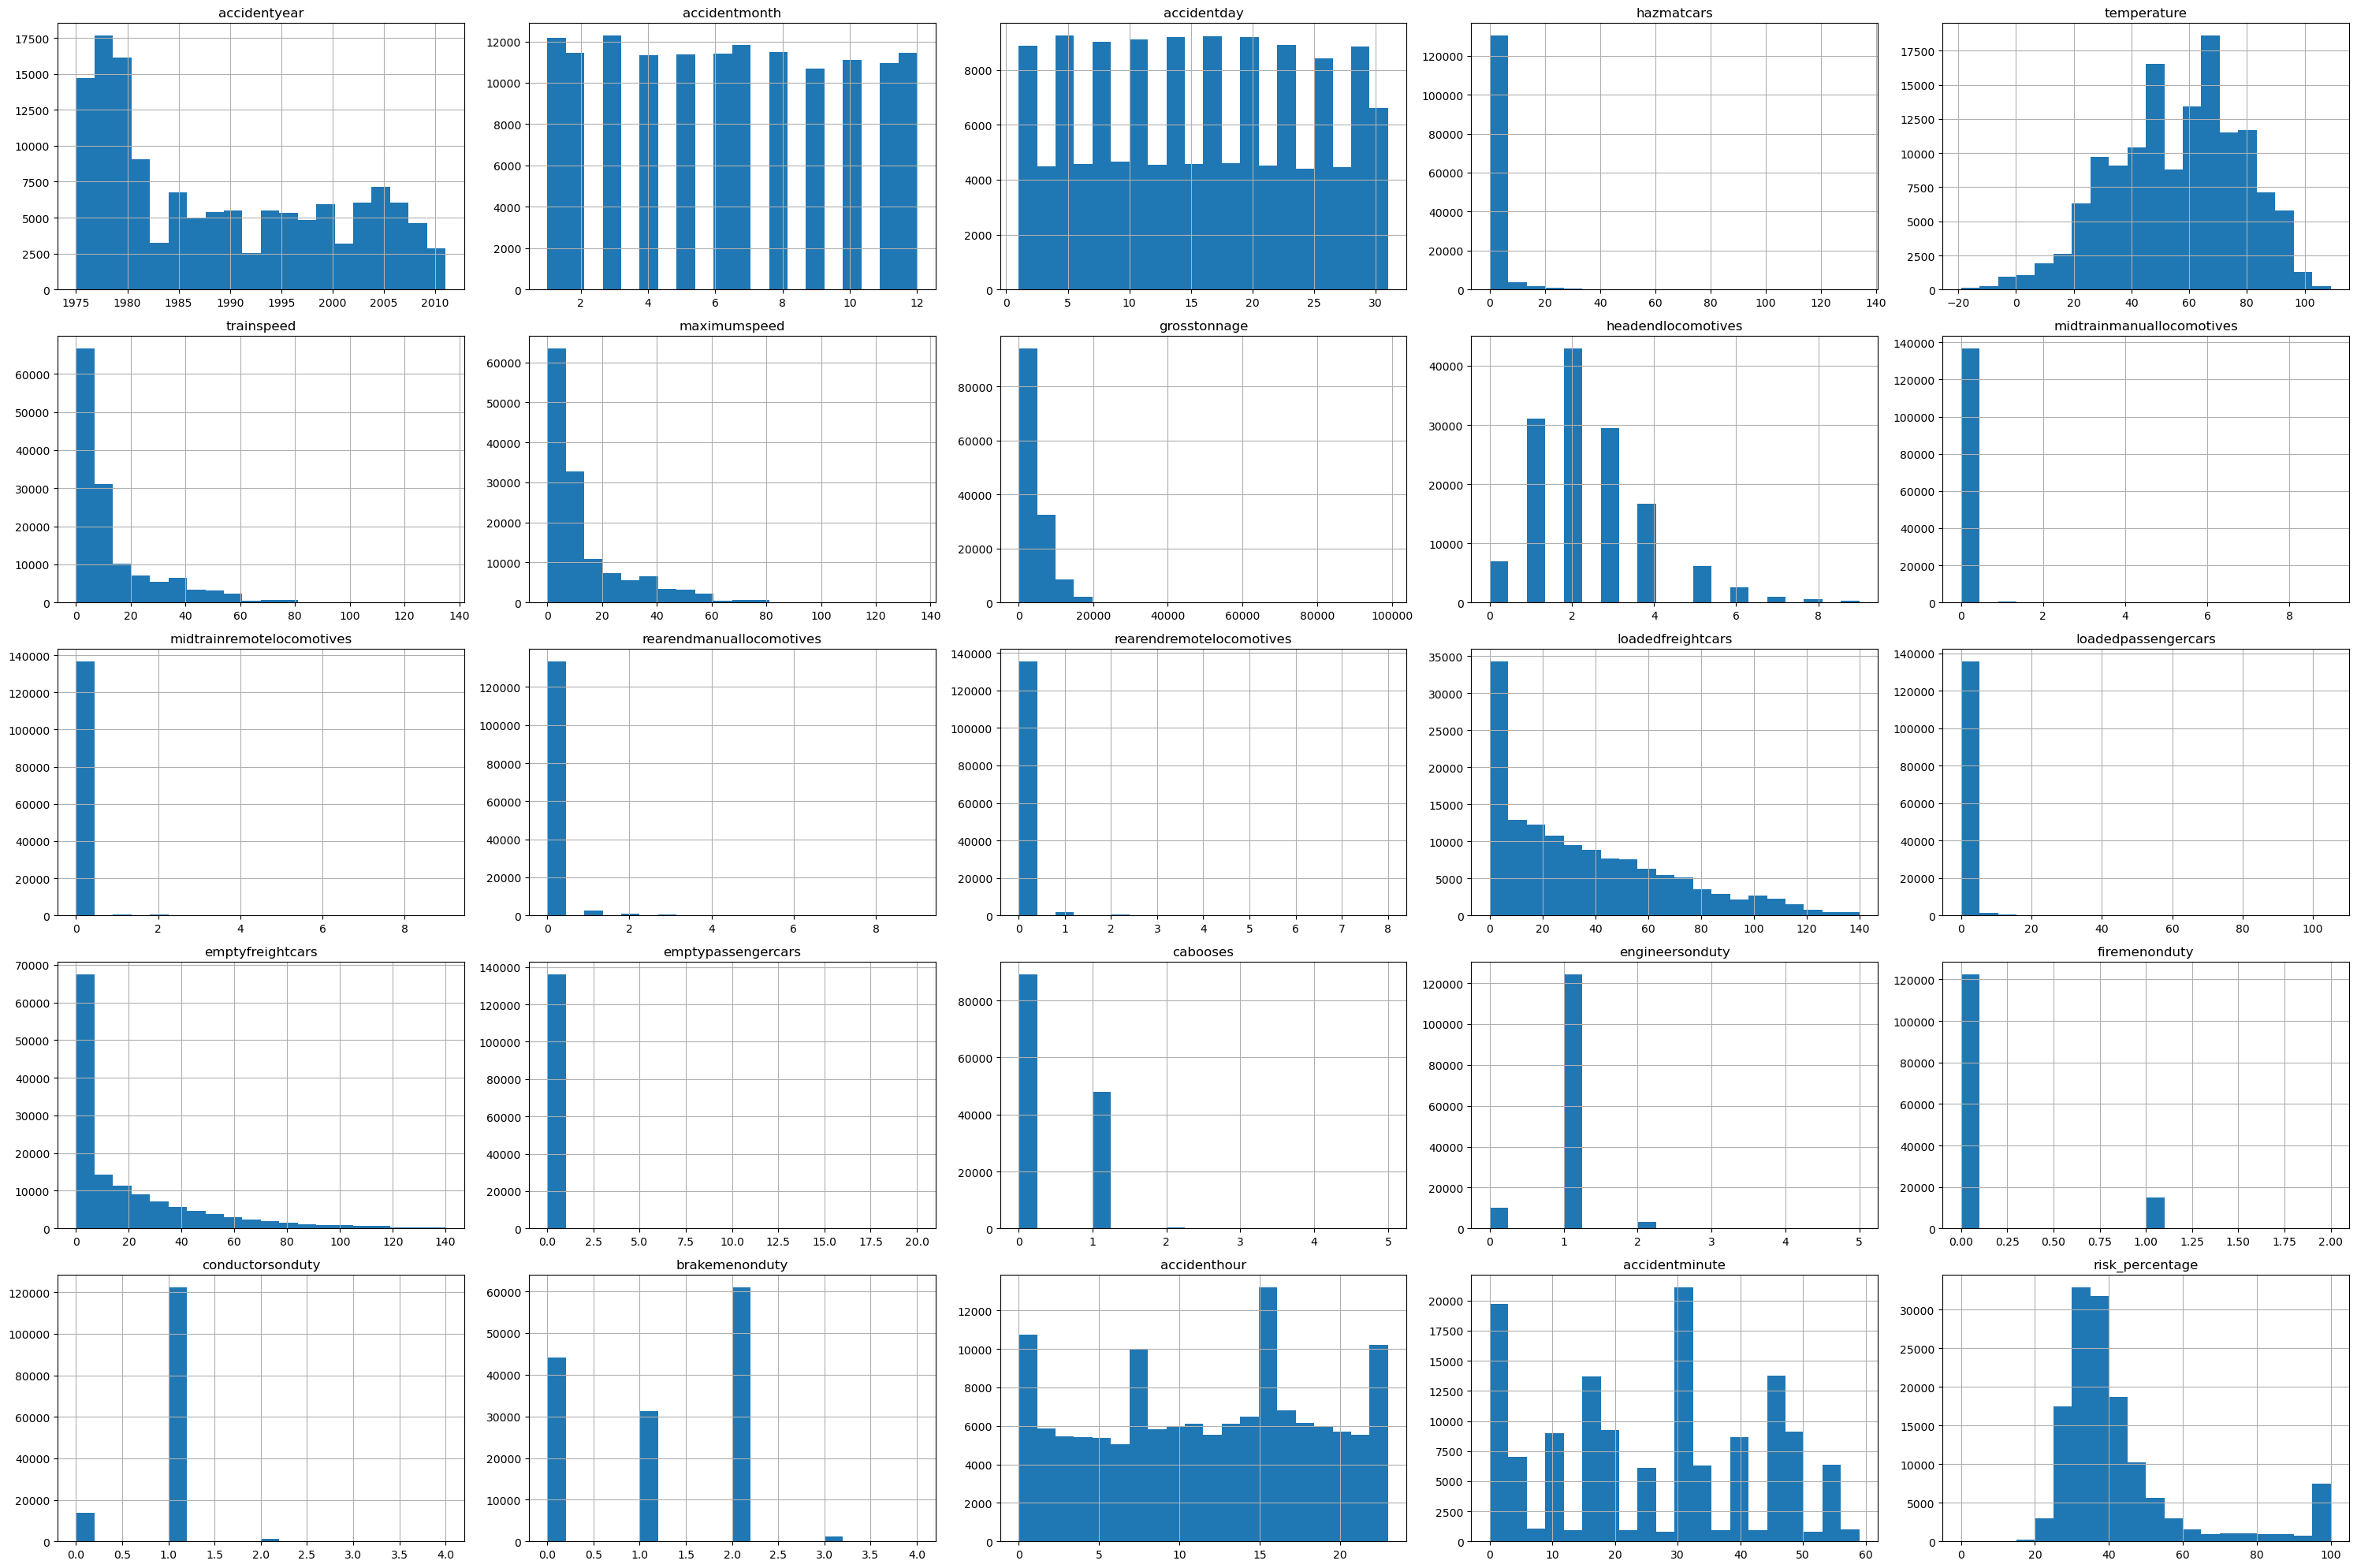

In [67]:
# Display distribution of numeric features
dist = df_a.hist(figsize=(30,20), bins = 20)
plt.tight_layout()
plt.show()

In [68]:
# Display description of numeric features
display(df_a.describe())

# Display shape of dataframe
print(f'Shape:{df_a.shape}')

,accidentyear,accidentmonth,accidentday,hazmatcars,temperature,trainspeed,maximumspeed,grosstonnage,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,engineersonduty,firemenonduty,conductorsonduty,brakemenonduty,accidenthour,accidentminute,risk_percentage
count,137457.000000,137457.000000,137457.000000,137457.00000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137457.000000,137436.000000,137436.000000,137457.000000
mean,1988.838429,6.415730,15.656031,1.21849,55.736529,13.518693,13.995926,3754.980707,2.410696,0.016158,0.016383,0.052009,0.021083,34.661771,0.197174,18.780171,0.061175,0.356577,0.952261,0.110987,0.909295,1.141179,11.691995,25.675376,42.506646
std,11.063473,3.461232,8.761188,5.26635,22.170468,15.284800,15.281405,4311.104660,1.440927,0.239236,0.232731,0.343759,0.187315,32.286833,1.600576,25.885316,0.684855,0.490738,0.313978,0.316126,0.324241,0.884134,6.782698,17.333474,17.824825
min,1975.000000,1.000000,1.000000,0.00000,-19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1979.000000,3.000000,8.000000,0.00000,40.000000,4.000000,5.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,6.000000,10.000000,32.281626
50%,1986.000000,6.000000,16.000000,0.00000,58.000000,7.000000,8.000000,2750.000000,2.000000,0.000000,0.000000,0.000000,0.000000,27.000000,0.000000,7.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,12.000000,30.000000,37.157369
75%,1999.000000,9.000000,23.000000,0.00000,73.000000,18.000000,19.000000,5890.000000,3.000000,0.000000,0.000000,0.000000,0.000000,55.000000,0.000000,29.000000,0.000000,1.000000,1.000000,0.000000,1.000000,2.000000,17.000000,40.000000,44.678830
max,2011.000000,12.000000,31.000000,134.00000,109.000000,135.000000,135.000000,99000.000000,9.000000,9.000000,9.000000,9.000000,8.000000,140.000000,105.000000,140.000000,20.000000,5.000000,5.000000,2.000000,4.000000,4.000000,23.000000,59.000000,100.000000


Shape:(137457, 41)


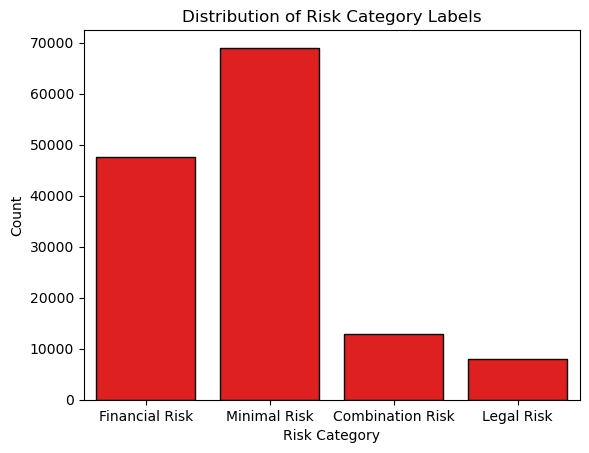

In [69]:
# Display chart of class imbalance
# Financial Risk and Minimal Risk were the highest, while Combination Risk and Legal Risk were the lowest.
# Worth Exploring
sns.countplot(df_a, x='risk_category', color = 'red', edgecolor = 'black')
plt.title('Distribution of Risk Category Labels')
plt.xlabel('Risk Category')
plt.ylabel('Count')
plt.show()

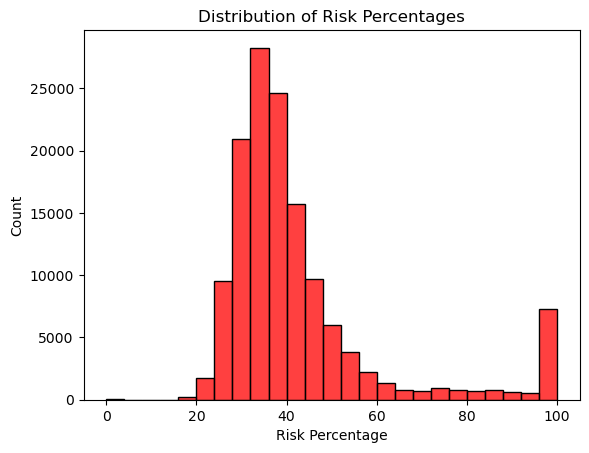

In [70]:
# Display distribution of risk percentage
# Little bit of a right skewed. Overall solid bell-shape with a high peak at 100%.
sns.histplot(data = df_a, x='risk_percentage', color = 'red', edgecolor = 'black', bins = 25)
plt.title('Distribution of Risk Percentages')
plt.xlabel('Risk Percentage')
plt.ylabel('Count')
plt.show()

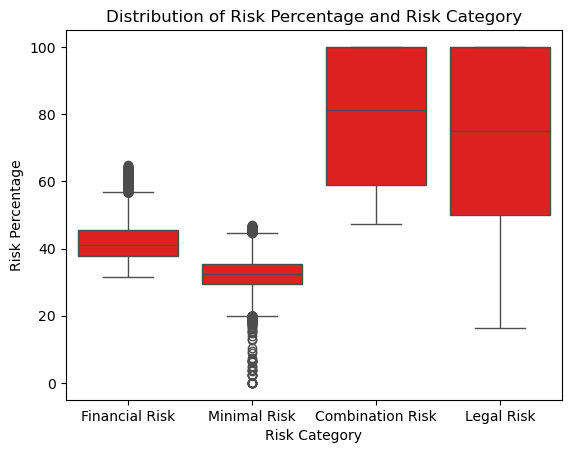

In [71]:
# Display boxplot of class category and percentage risk
# Presence of outliers in the Financial Risk and Minimal Risk. Combination Risk and Legal Risk represent the portion of the data sitting at 100%. 
sns.boxplot(data=df_a, x = 'risk_category', y = 'risk_percentage', color = 'red')
plt.title('Distribution of Risk Percentage and Risk Category')
plt.xlabel('Risk Category')
plt.ylabel('Risk Percentage')
plt.show()

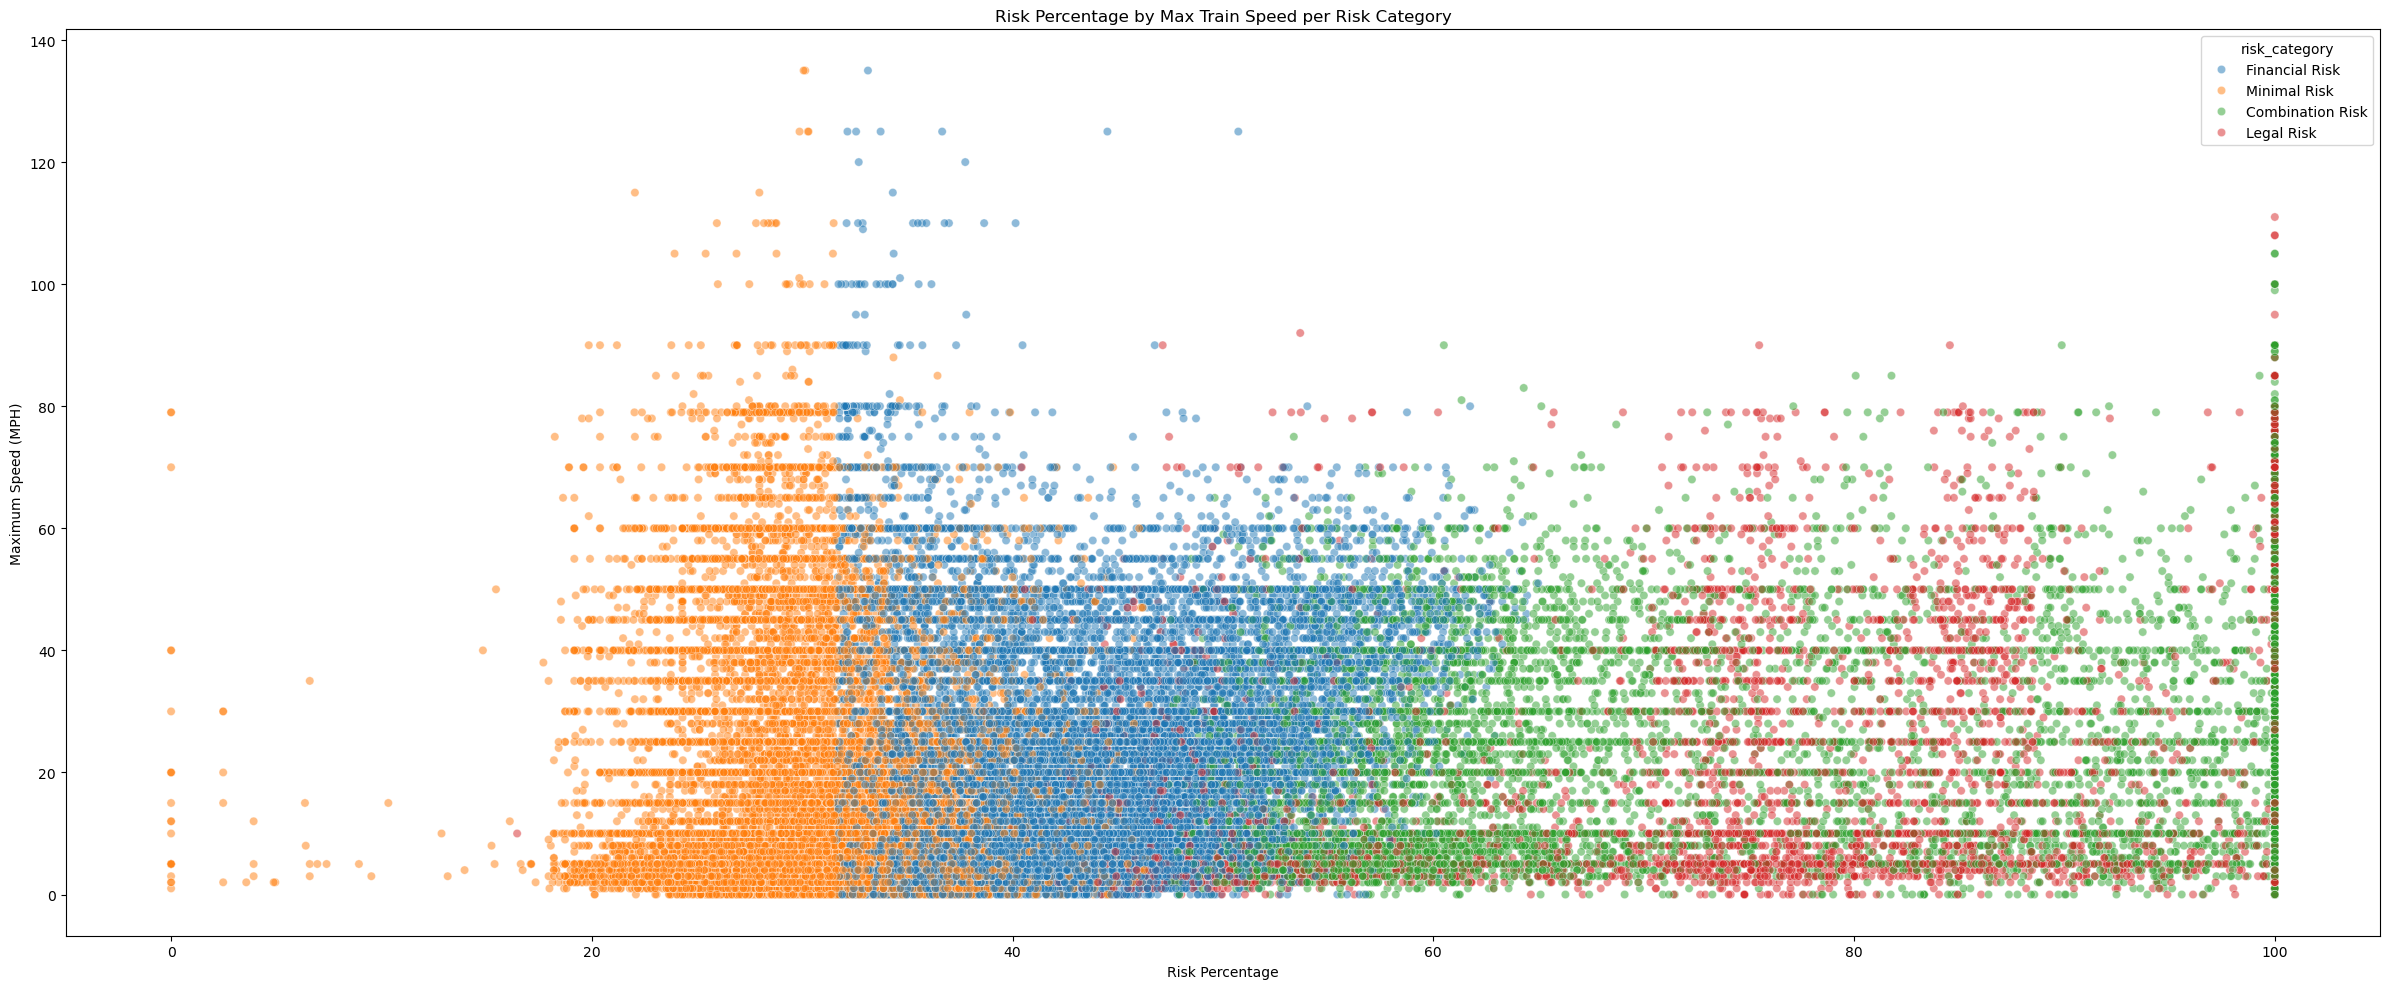

In [72]:
# Display correlation to Max Speed and Risk Percentage
# Maxspeed isn't really useful here, but this was used to show the categories are almost grouped into their sections.
# Legal and Combination Risk sharing the same space, but legal is more closly packed.
plt.figure(figsize=(24,10))
sns.scatterplot(data=df_a, x = 'risk_percentage', y = 'maximumspeed', hue = 'risk_category', alpha = 0.5)
plt.title('Risk Percentage by Max Train Speed per Risk Category')
plt.xlabel('Risk Percentage')
plt.ylabel('Maximum Speed (MPH)')
plt.tight_layout()
plt.show()

In [73]:
# Calculate correlation score to target variable
# No alarmingly strong correlations
corr_risk_percent = df_a.corr(numeric_only = True)['risk_percentage']
print(corr_risk_percent)

accidentyear                 0.099503
accidentmonth                0.000711
accidentday                  0.007261
hazmatcars                   0.153095
temperature                  0.019526
trainspeed                   0.340211
maximumspeed                 0.353531
grosstonnage                 0.110677
headendlocomotives           0.103581
midtrainmanuallocomotives    0.029552
midtrainremotelocomotives    0.038388
rearendmanuallocomotives     0.019833
rearendremotelocomotives     0.069391
loadedfreightcars            0.082709
loadedpassengercars          0.133027
emptyfreightcars             0.017079
emptypassengercars           0.048527
cabooses                     0.019912
engineersonduty              0.076527
firemenonduty                0.049386
conductorsonduty             0.081456
brakemenonduty              -0.051507
accidenthour                -0.004895
accidentminute               0.034083
risk_percentage              1.000000
Name: risk_percentage, dtype: float64


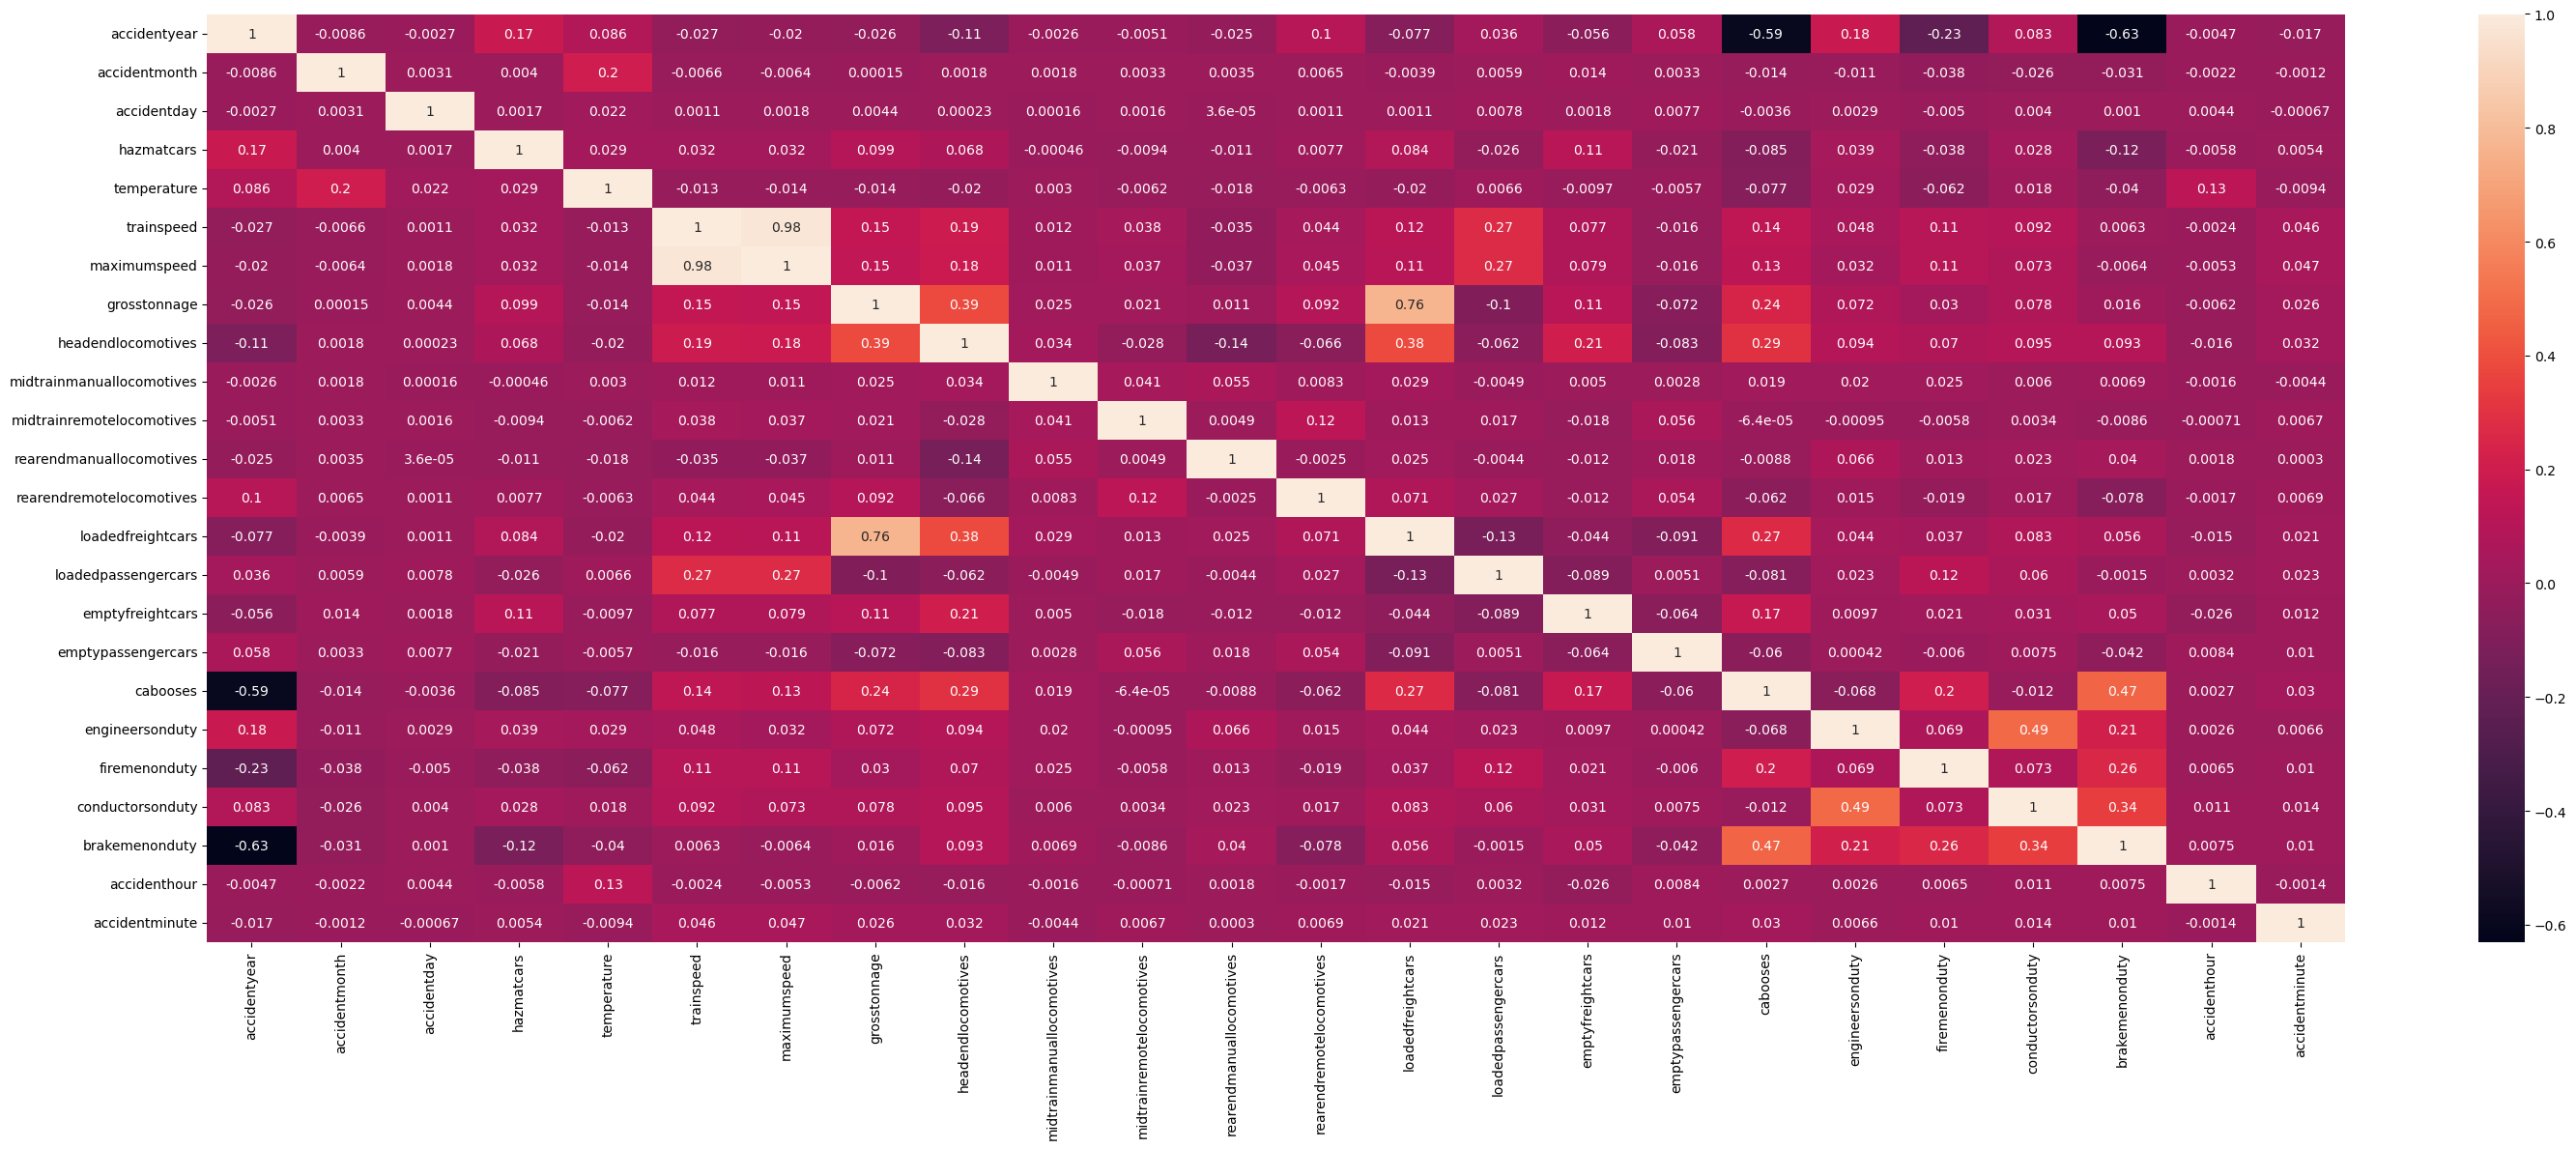

In [74]:
# Visual display of correlated features
# No alarming correlations
plt.figure(figsize = (30,12))
heat_data = df_a.drop(columns = ['risk_percentage']).corr(numeric_only=True)
ax = sns.heatmap(heat_data, annot = True)
plt.tight_layout()

### One Hot Encoding

In [75]:
# Set features used for encoding
df_hot_encod = ['accidenttype',
                'tracktype',
                'equipmentattended',
                'recordedestimatedspeed',
                'passengerstransported',
                'jointtrackclass',
                'class',
                'weatherconditioncode',
                'visibilitycode']

In [76]:
# Create dummy variables
df_encoded = pd.get_dummies(df_a, columns = df_hot_encod, dtype = int, drop_first = True)

# Reformatting column names
# Turn columns to lowercase
df_encoded.columns = df_encoded.columns.str.lower()

# Remove space between columns
df_encoded.columns = df_encoded.columns.str.replace(" ","_")

In [77]:
# Display data and shape
display(df_encoded.head(1))
print(f'Shape:{df_encoded.shape}')

,reportingrailroadcode,maintenancerailroadcode,accidentyear,accidentmonth,accidentday,division,stateabbreviation,countyname,district,hazmatcars,temperature,trainspeed,maximumspeed,grosstonnage,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,engineersonduty,firemenonduty,conductorsonduty,brakemenonduty,accidenthour,accidentminute,risk_percentage,risk_category,accidenttype_derailment,accidenttype_explosion-detonation,accidenttype_fire/violent_rupture,accidenttype_head_on_collision,accidenttype_hwy-rail_crossing,accidenttype_obstruction,accidenttype_other_impacts,accidenttype_rr_grade_crossing,accidenttype_raking_collision,accidenttype_rear_end_collision,accidenttype_side_collision,tracktype_main,tracktype_siding,tracktype_yard,equipmentattended_unknown,equipmentattended_yes,recordedestimatedspeed_recorded,passengerstransported_unknown,passengerstransported_yes,jointtrackclass_1,jointtrackclass_2,jointtrackclass_3,jointtrackclass_4,jointtrackclass_5,jointtrackclass_6,jointtrackclass_7,jointtrackclass_8,jointtrackclass_9,jointtrackclass_x,class_1l,class_1s,class_2,class_2l,class_2s,class_3,class_3l,class_3s,class_6,class_cl,weatherconditioncode_1.0,weatherconditioncode_2.0,weatherconditioncode_3.0,weatherconditioncode_4.0,weatherconditioncode_5.0,weatherconditioncode_6.0,weatherconditioncode_nan,visibilitycode_1.0,visibilitycode_2.0,visibilitycode_3.0,visibilitycode_4.0,visibilitycode_nan
1,BNSF,BNSF,2010,12,24,KANSAS,KS,COWLEY,6,0,35,21.0,21.0,14755,3,0,0,0,1,114,0,1,0,0,1.0,0.0,1.0,0.0,16.0,30.0,53.438041,Financial Risk,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0


Shape:(137457, 83)


In [78]:
# Display column names
df_encoded.columns

Index(['reportingrailroadcode', 'maintenancerailroadcode', 'accidentyear',
       'accidentmonth', 'accidentday', 'division', 'stateabbreviation',
       'countyname', 'district', 'hazmatcars', 'temperature', 'trainspeed',
       'maximumspeed', 'grosstonnage', 'headendlocomotives',
       'midtrainmanuallocomotives', 'midtrainremotelocomotives',
       'rearendmanuallocomotives', 'rearendremotelocomotives',
       'loadedfreightcars', 'loadedpassengercars', 'emptyfreightcars',
       'emptypassengercars', 'cabooses', 'engineersonduty', 'firemenonduty',
       'conductorsonduty', 'brakemenonduty', 'accidenthour', 'accidentminute',
       'risk_percentage', 'risk_category', 'accidenttype_derailment',
       'accidenttype_explosion-detonation',
       'accidenttype_fire/violent_rupture', 'accidenttype_head_on_collision',
       'accidenttype_hwy-rail_crossing', 'accidenttype_obstruction',
       'accidenttype_other_impacts', 'accidenttype_rr_grade_crossing',
       'accidenttype_raking_c

### Seperating Data 

In [79]:
# Seperate data into two dataframe. One target variable each
score_df = df_encoded.drop(columns = ['risk_category']).copy()
category_df = df_encoded.drop(columns = ['risk_percentage']).copy()

# Display data
display(score_df.head(1))
display(category_df.head(1))

,reportingrailroadcode,maintenancerailroadcode,accidentyear,accidentmonth,accidentday,division,stateabbreviation,countyname,district,hazmatcars,temperature,trainspeed,maximumspeed,grosstonnage,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,engineersonduty,firemenonduty,conductorsonduty,brakemenonduty,accidenthour,accidentminute,risk_percentage,accidenttype_derailment,accidenttype_explosion-detonation,accidenttype_fire/violent_rupture,accidenttype_head_on_collision,accidenttype_hwy-rail_crossing,accidenttype_obstruction,accidenttype_other_impacts,accidenttype_rr_grade_crossing,accidenttype_raking_collision,accidenttype_rear_end_collision,accidenttype_side_collision,tracktype_main,tracktype_siding,tracktype_yard,equipmentattended_unknown,equipmentattended_yes,recordedestimatedspeed_recorded,passengerstransported_unknown,passengerstransported_yes,jointtrackclass_1,jointtrackclass_2,jointtrackclass_3,jointtrackclass_4,jointtrackclass_5,jointtrackclass_6,jointtrackclass_7,jointtrackclass_8,jointtrackclass_9,jointtrackclass_x,class_1l,class_1s,class_2,class_2l,class_2s,class_3,class_3l,class_3s,class_6,class_cl,weatherconditioncode_1.0,weatherconditioncode_2.0,weatherconditioncode_3.0,weatherconditioncode_4.0,weatherconditioncode_5.0,weatherconditioncode_6.0,weatherconditioncode_nan,visibilitycode_1.0,visibilitycode_2.0,visibilitycode_3.0,visibilitycode_4.0,visibilitycode_nan
1,BNSF,BNSF,2010,12,24,KANSAS,KS,COWLEY,6,0,35,21.0,21.0,14755,3,0,0,0,1,114,0,1,0,0,1.0,0.0,1.0,0.0,16.0,30.0,53.438041,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0


,reportingrailroadcode,maintenancerailroadcode,accidentyear,accidentmonth,accidentday,division,stateabbreviation,countyname,district,hazmatcars,temperature,trainspeed,maximumspeed,grosstonnage,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,engineersonduty,firemenonduty,conductorsonduty,brakemenonduty,accidenthour,accidentminute,risk_category,accidenttype_derailment,accidenttype_explosion-detonation,accidenttype_fire/violent_rupture,accidenttype_head_on_collision,accidenttype_hwy-rail_crossing,accidenttype_obstruction,accidenttype_other_impacts,accidenttype_rr_grade_crossing,accidenttype_raking_collision,accidenttype_rear_end_collision,accidenttype_side_collision,tracktype_main,tracktype_siding,tracktype_yard,equipmentattended_unknown,equipmentattended_yes,recordedestimatedspeed_recorded,passengerstransported_unknown,passengerstransported_yes,jointtrackclass_1,jointtrackclass_2,jointtrackclass_3,jointtrackclass_4,jointtrackclass_5,jointtrackclass_6,jointtrackclass_7,jointtrackclass_8,jointtrackclass_9,jointtrackclass_x,class_1l,class_1s,class_2,class_2l,class_2s,class_3,class_3l,class_3s,class_6,class_cl,weatherconditioncode_1.0,weatherconditioncode_2.0,weatherconditioncode_3.0,weatherconditioncode_4.0,weatherconditioncode_5.0,weatherconditioncode_6.0,weatherconditioncode_nan,visibilitycode_1.0,visibilitycode_2.0,visibilitycode_3.0,visibilitycode_4.0,visibilitycode_nan
1,BNSF,BNSF,2010,12,24,KANSAS,KS,COWLEY,6,0,35,21.0,21.0,14755,3,0,0,0,1,114,0,1,0,0,1.0,0.0,1.0,0.0,16.0,30.0,Financial Risk,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0


### Test Train Split Practice

In [80]:
# Seperating features and variables
X = score_df.drop(columns = ['risk_percentage'])
y = score_df['risk_percentage']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

#### Frequency Calculation

In [81]:
# Set features used for frequency
df_freq_encod = ['reportingrailroadcode',
                 'maintenancerailroadcode',
                 'stateabbreviation',
                 'district',
                 'division',
                 'countyname']

In [82]:
# Claude AI was used to help trouble shoot coding logic to avoid data leaking 
for i in df_freq_encod:
    frequency = X_train[i].value_counts(normalize=True) # Value count as a percentage per feature column
    X_train[i + 'fq'] = X_train[i].map(frequency) # Replace category value with it frequency value in training
    X_test[i + 'fq'] = X_test[i].map(frequency) # Follows the same principle but in testing
    X_test[i + 'fq'] = X_test[i + 'fq'].fillna(0) # If not present, fill with 0

X_train = X_train.drop(columns = df_freq_encod) # Drop redundent columns
X_test = X_test.drop(columns = df_freq_encod) # Drop redundent columns

In [83]:
# Display data and shape
display(X_train.head(3))
print(X_train.shape)

,accidentyear,accidentmonth,accidentday,hazmatcars,temperature,trainspeed,maximumspeed,grosstonnage,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,engineersonduty,firemenonduty,conductorsonduty,brakemenonduty,accidenthour,accidentminute,accidenttype_derailment,accidenttype_explosion-detonation,accidenttype_fire/violent_rupture,accidenttype_head_on_collision,accidenttype_hwy-rail_crossing,accidenttype_obstruction,accidenttype_other_impacts,accidenttype_rr_grade_crossing,accidenttype_raking_collision,accidenttype_rear_end_collision,accidenttype_side_collision,tracktype_main,tracktype_siding,tracktype_yard,equipmentattended_unknown,equipmentattended_yes,recordedestimatedspeed_recorded,passengerstransported_unknown,passengerstransported_yes,jointtrackclass_1,jointtrackclass_2,jointtrackclass_3,jointtrackclass_4,jointtrackclass_5,jointtrackclass_6,jointtrackclass_7,jointtrackclass_8,jointtrackclass_9,jointtrackclass_x,class_1l,class_1s,class_2,class_2l,class_2s,class_3,class_3l,class_3s,class_6,class_cl,weatherconditioncode_1.0,weatherconditioncode_2.0,weatherconditioncode_3.0,weatherconditioncode_4.0,weatherconditioncode_5.0,weatherconditioncode_6.0,weatherconditioncode_nan,visibilitycode_1.0,visibilitycode_2.0,visibilitycode_3.0,visibilitycode_4.0,visibilitycode_nan,reportingrailroadcodefq,maintenancerailroadcodefq,stateabbreviationfq,districtfq,divisionfq,countynamefq
167191,1977,4,22,2,84,30.0,30.0,3880,3,0,0,0,0,30,0,62,0,1,1.0,0.0,1.0,2.0,12.0,40.0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0.071649,0.070558,0.044357,0.126940,0.005061,0.000915
41764,1988,3,29,0,50,40.0,40.0,3305,2,0,0,0,0,0,0,94,0,0,1.0,0.0,1.0,2.0,3.0,0.0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0.014987,0.014467,0.082707,0.171827,0.001517,0.005903
136373,1979,5,4,0,40,5.0,5.0,4700,2,0,0,0,0,20,0,16,0,1,1.0,0.0,1.0,2.0,23.0,50.0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0.012908,0.012659,0.022584,0.171827,0.004895,0.009011


(96219, 81)


In [84]:
# Display data and shape
display(X_test.head(3))
print(X_test.shape)

,accidentyear,accidentmonth,accidentday,hazmatcars,temperature,trainspeed,maximumspeed,grosstonnage,headendlocomotives,midtrainmanuallocomotives,midtrainremotelocomotives,rearendmanuallocomotives,rearendremotelocomotives,loadedfreightcars,loadedpassengercars,emptyfreightcars,emptypassengercars,cabooses,engineersonduty,firemenonduty,conductorsonduty,brakemenonduty,accidenthour,accidentminute,accidenttype_derailment,accidenttype_explosion-detonation,accidenttype_fire/violent_rupture,accidenttype_head_on_collision,accidenttype_hwy-rail_crossing,accidenttype_obstruction,accidenttype_other_impacts,accidenttype_rr_grade_crossing,accidenttype_raking_collision,accidenttype_rear_end_collision,accidenttype_side_collision,tracktype_main,tracktype_siding,tracktype_yard,equipmentattended_unknown,equipmentattended_yes,recordedestimatedspeed_recorded,passengerstransported_unknown,passengerstransported_yes,jointtrackclass_1,jointtrackclass_2,jointtrackclass_3,jointtrackclass_4,jointtrackclass_5,jointtrackclass_6,jointtrackclass_7,jointtrackclass_8,jointtrackclass_9,jointtrackclass_x,class_1l,class_1s,class_2,class_2l,class_2s,class_3,class_3l,class_3s,class_6,class_cl,weatherconditioncode_1.0,weatherconditioncode_2.0,weatherconditioncode_3.0,weatherconditioncode_4.0,weatherconditioncode_5.0,weatherconditioncode_6.0,weatherconditioncode_nan,visibilitycode_1.0,visibilitycode_2.0,visibilitycode_3.0,visibilitycode_4.0,visibilitycode_nan,reportingrailroadcodefq,maintenancerailroadcodefq,stateabbreviationfq,districtfq,divisionfq,countynamefq
113376,1985,5,13,0,60,10.0,10.0,5600,3,0,0,0,0,80,0,0,0,0,1.0,0.0,1.0,1.0,19.0,31.0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0.071649,0.070558,0.082707,0.171827,0.030836,0.035845
51644,2000,9,14,0,73,3.0,3.0,2308,2,0,0,0,0,3,0,14,0,0,1.0,0.0,1.0,1.0,12.0,30.0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0.008262,0.008595,0.082707,0.171827,0.005612,0.035845
48716,1996,6,27,1,70,4.0,4.0,310,2,0,0,0,0,2,0,2,0,0,1.0,0.0,1.0,1.0,18.0,25.0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0.071649,0.070558,0.030898,0.171827,0.002193,0.001736


(41238, 81)


#### Standard Scaler

In [85]:
scaler = StandardScaler() # Assigning the scaler
X_train_scaled = scaler.fit_transform(X_train) # Impliment on the training data
X_test_scaled = scaler.transform(X_test) # Transform testiong using the mean and std from training calculation
print(X_train_scaled) 

[[-1.06738783 -0.69860726  0.7243032  ... -0.33495407 -0.40912672
  -0.52405304]
 [-0.07168281 -0.98761931  1.52470437 ...  0.87922664 -0.56033435
   0.09484141]
 [-0.88635056 -0.4095952  -1.33387122 ...  0.87922664 -0.41622151
   0.48036108]
 ...
 [-1.06738783 -0.98761931 -1.56255727 ...  0.87922664  0.08130035
  -0.5678914 ]
 [-1.06738783  1.03546509  0.03824506 ...  0.43842198 -0.62064003
   0.33466301]
 [-1.15790647 -0.69860726 -0.7621561  ...  0.43842198 -0.58560952
  -0.50729131]]
